# V16: Multi-GNN — Fixed RGCN/SGNN + 7-dim Patient Features + ba_m HPO + Weighted Ensemble

**New in V16 over V15:**
- **Fix RGCN** (Cell 6): GATv2 Gene->Patient aggregation added before RGCN on PP-layer. Gene mutations were completely ignored in V15.
- **Fix SGNN** (Cell 6): GATv2 Gene->Patient pre-aggregation before ChebConv. Gene mutations were completely ignored in V15.
- **Enriched Patient Features** (Cell 4/4b): `Patient.x` expanded 3->7: Gender, Race, Age_norm, MutBurden, RTK_score, IDH_score, TP53_score.
- **ba_m as Optuna Hyperparameter** (Cell 10): BA attachment count tuned in {1..5}; each trial rebuilds graph dynamically with its own ba_m.
- **Pipeline E - AUC-Weighted Ensemble**: All 7 models per pipeline combined by their TCGA test AUC weights. Evaluated on TCGA Test + CGGA.
- All V15 improvements retained: sqrt-penalty, G-mean threshold, 5-Fold CV, scale-free BA graphs, DAHGNN.


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, GCNConv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

import os

def set_seed(seed=42):
    """Full determinism:
    - Python / NumPy / PyTorch RNGs
    - cuDNN deterministic algorithms (no non-deterministic scatter ops)
    - PYTHONHASHSEED for dict/set ordering
    NOTE: cudnn.deterministic=True adds ~10-20% training overhead.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True   # no non-det cuDNN kernels
    torch.backends.cudnn.benchmark     = False  # disable auto-tuner (picks diff algo each run)

set_seed(42)

N_TRIALS   = 30    # Optuna TPE trials per model×pipeline
N_FOLDS    = 5     # stratified CV folds
MAX_EPOCHS = 200
PATIENCE   = 20

/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libnvToolsExt.so.1: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "


Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## 2. Load Data

In [2]:
tcga_df = pd.read_csv('../../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)

print("TCGA:", tcga_df.shape, "  Grade dist:", dict(tcga_df['Grade'].value_counts()))
print("CGGA:", cgga_df.shape, "  Grade dist:", dict(cgga_df['Grade'].value_counts()))

TCGA: (839, 24)   Grade dist: {0: 487, 1: 352}
CGGA: (286, 24)   Grade dist: {0: 184, 1: 102}


## 3. Splits — 20% held-out test; remaining 80% used for HPO + 5-Fold CV

In [3]:
# Hold out 20% as final test set (never seen during HPO or CV)
train_val_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)

# Further split train_val for Optuna HPO warmup (val graph used only in HPO phase)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['Grade'], random_state=42)

print(f"Train(HPO)={len(train_df)}  Val(HPO)={len(val_df)}  "
      f"TrainVal(CV)={len(train_val_df)}  Test={len(test_df)}")
print("Train Grade dist:", dict(train_df['Grade'].value_counts()))
print("Test  Grade dist:", dict(test_df['Grade'].value_counts()))

Train(HPO)=536  Val(HPO)=135  TrainVal(CV)=671  Test=168
Train Grade dist: {0: 311, 1: 225}
Test  Grade dist: {0: 98, 1: 70}


## 4. Graph Construction

In [4]:
_PP_CACHE: dict = {}

# ── V16: Biologically motivated pathway gene groups ──────────────
RTK_GENES  = ['EGFR', 'PDGFRA', 'PIK3CA', 'PIK3R1', 'PTEN', 'NF1']
IDH_GENES  = ['IDH1', 'IDH2']
TP53_GENES = ['TP53', 'ATRX', 'RB1']
PAT_FEAT_DIM = 7   # Gender + Race + Age_norm + MutBurden + RTK + IDH + TP53


def _build_patient_features(df):
    """Build enriched 7-dim patient feature matrix.
    Columns: [Gender, Race, Age_norm, MutBurden, RTK_score, IDH_score, TP53_score]
    Enriching from 3 clinical features to 7 gives all models richer node signals
    and reduces the information bottleneck for models like RGCN and SGNN.
    """
    import warnings; warnings.filterwarnings('ignore')
    age_norm   = StandardScaler().fit_transform(df[['Age_at_diagnosis']]).astype('float32')
    mut_burden = StandardScaler().fit_transform(
        df[gene_columns].sum(axis=1).values.reshape(-1,1).astype('float32')
    )
    rtk_cols  = [g for g in RTK_GENES  if g in df.columns]
    idh_cols  = [g for g in IDH_GENES  if g in df.columns]
    tp53_cols = [g for g in TP53_GENES if g in df.columns]
    rtk_score  = df[rtk_cols].sum(axis=1).values.reshape(-1,1).astype('float32')  if rtk_cols  else np.zeros((len(df),1),'float32')
    idh_score  = df[idh_cols].sum(axis=1).values.reshape(-1,1).astype('float32')  if idh_cols  else np.zeros((len(df),1),'float32')
    tp53_score = df[tp53_cols].sum(axis=1).values.reshape(-1,1).astype('float32') if tp53_cols else np.zeros((len(df),1),'float32')
    return np.hstack([
        df[['Gender','Race']].values.astype('float32'),
        age_norm, mut_burden, rtk_score, idh_score, tp53_score
    ])   # (n_patients, 7)


def construct_bipartite_heterograph(df):
    """Bipartite heterograph with V16 enriched 7-dim patient features."""
    graph = HeteroData()
    graph['Patient'].x = torch.tensor(_build_patient_features(df), dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    graph['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)
    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx); dst_patients.append(p_idx)
    graph['Gene','mutates','Patient'].edge_index    = torch.tensor([src_genes, dst_patients], dtype=torch.long)
    graph['Patient','mutated_by','Gene'].edge_index = torch.tensor([dst_patients, src_genes], dtype=torch.long)
    return graph


def get_pp_edges(graph, max_pts=30):
    key = id(graph)
    if key in _PP_CACHE: return _PP_CACHE[key]
    ei = graph[('Gene','mutates','Patient')].edge_index.cpu()
    gene_ids, pat_ids = ei[0], ei[1]
    n_p = graph['Patient'].x.shape[0]
    all_src, all_dst, all_types = [], [], []
    torch.manual_seed(42)
    for g in range(NUM_GENES):
        mask = (gene_ids==g); pts = pat_ids[mask].unique(); n = len(pts)
        if n < 2: continue
        if n > max_pts: pts = pts[torch.randperm(n)[:max_pts]]; n = max_pts
        src = pts.repeat_interleave(n); dst = pts.repeat(n)
        valid = (src != dst)
        all_src.append(src[valid]); all_dst.append(dst[valid])
        all_types.append(torch.full((valid.sum(),), g, dtype=torch.long))
    if all_src:
        pp_ei = torch.stack([torch.cat(all_src), torch.cat(all_dst)])
        pp_et = torch.cat(all_types)
    else:
        idx = torch.arange(n_p)
        pp_ei = torch.stack([idx,idx]); pp_et = torch.zeros(n_p,dtype=torch.long)
    _PP_CACHE[key] = (pp_ei, pp_et)
    return pp_ei, pp_et


def to_dev(graph): return graph.to(device)
def clear_pp_cache(): _PP_CACHE.clear()

print(f'V16 patient feature dim: {PAT_FEAT_DIM}')
print('Features: Gender, Race, Age_norm, MutBurden, RTK_score, IDH_score, TP53_score')


V16 patient feature dim: 7
Features: Gender, Race, Age_norm, MutBurden, RTK_score, IDH_score, TP53_score


## 4a. Scale-Free Analysis — Degree Distribution Proof

SCALE-FREE ANALYSIS - Original Bipartite Heterogeneous Graph

  Graph type  : Bipartite HeteroData  (Gene <-> Patient)
  Patient nodes : [Gender, Race, Age_norm]  (N ~800+)
  Gene nodes    : one-hot identity          (N = 20)
  Edges         : Gene->Patient if mutation bit == 1


———————————————————————————————————————————————————————
  Patient-side degrees
———————————————————————————————————————————————————————
  Degree range       : [0, 17]
  Mean +/- Std       : 2.27 +/- 1.49
  Power-law gamma    : 2.125  (scale-free: 2 < gamma < 3)
  R2 power-law       : 0.7303
  R2 exponential     : 0.6229
  KS p-value (PL)    : 0.9801  (p>0.05 = good PL fit)
  Verdict            : SCALE-FREE

———————————————————————————————————————————————————————
  Gene-side degrees
———————————————————————————————————————————————————————
  Degree range       : [18, 322]
  Mean +/- Std       : 76.25 +/- 82.92
  Power-law gamma    : 0.134  (scale-free: 2 < gamma < 3)
  R2 power-law       : 0.2005
  R2 exponential 

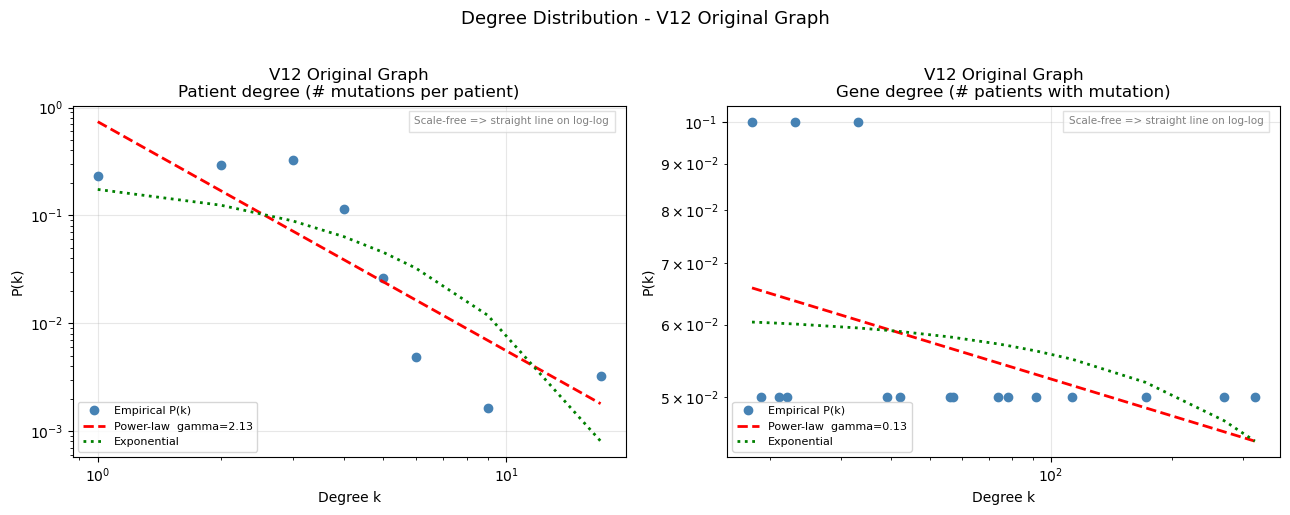

In [5]:
from scipy import stats

def get_degree_sequences(graph):
    ei       = graph[("Gene","mutates","Patient")].edge_index.cpu()
    gene_ids = ei[0].numpy(); pat_ids = ei[1].numpy()
    pat_deg  = np.bincount(pat_ids,  minlength=graph["Patient"].x.shape[0])
    gene_deg = np.bincount(gene_ids, minlength=graph["Gene"].x.shape[0])
    return pat_deg, gene_deg


def fit_powerlaw(degrees, label="Degrees"):
    k_vals, counts = np.unique(degrees[degrees > 0], return_counts=True)
    pmf   = counts / len(degrees[degrees > 0])
    log_k = np.log(k_vals.astype(float))
    log_p = np.log(pmf + 1e-12)

    sl_pl,  ic_pl,  r_pl,  *_ = stats.linregress(log_k, log_p)
    sl_exp, ic_exp, r_exp, *_ = stats.linregress(k_vals.astype(float), log_p)
    gamma  = -sl_pl
    r2_pl  = r_pl  ** 2
    r2_exp = r_exp ** 2

    fitted_pl = np.exp(ic_pl) * (k_vals ** sl_pl)
    fitted_pl = fitted_pl / fitted_pl.sum()
    _, ks_p   = stats.ks_2samp(pmf, fitted_pl)

    print(f"\n{chr(8212)*55}\n  {label}\n{chr(8212)*55}")
    print(f"  Degree range       : [{degrees.min()}, {degrees.max()}]")
    print(f"  Mean +/- Std       : {degrees.mean():.2f} +/- {degrees.std():.2f}")
    print(f"  Power-law gamma    : {gamma:.3f}  (scale-free: 2 < gamma < 3)")
    print(f"  R2 power-law       : {r2_pl:.4f}")
    print(f"  R2 exponential     : {r2_exp:.4f}")
    print(f"  KS p-value (PL)    : {ks_p:.4f}  (p>0.05 = good PL fit)")

    is_sf = r2_pl > r2_exp and 2 < gamma < 3 and ks_p > 0.05
    if is_sf:
        print("  Verdict            : SCALE-FREE")
    else:
        reasons = []
        if r2_pl <= r2_exp:  reasons.append(f"exp fits better (R2_exp={r2_exp:.3f} > R2_pl={r2_pl:.3f})")
        if not (2<gamma<3):  reasons.append(f"gamma={gamma:.2f} outside (2,3)")
        if ks_p <= 0.05:     reasons.append(f"KS rejects PL (p={ks_p:.4f})")
        print(f"  Reason(s)          : {'; '.join(reasons)}")
        print("  Verdict            : NOT SCALE-FREE")
    return gamma, r2_pl, r2_exp, ks_p


def plot_degree_distribution(pat_deg, gene_deg, title_prefix="Graph"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, degs, lbl in zip(
        axes,
        [pat_deg, gene_deg],
        ["Patient degree (# mutations per patient)",
         "Gene degree (# patients with mutation)"]
    ):
        k_vals, counts = np.unique(degs[degs > 0], return_counts=True)
        pmf = counts / len(degs[degs > 0])
        ax.loglog(k_vals, pmf, "o", color="steelblue", ms=6, label="Empirical P(k)")
        log_k, log_p = np.log(k_vals.astype(float)), np.log(pmf + 1e-12)
        sl_pl, ic_pl, *_ = stats.linregress(log_k, log_p)
        ax.loglog(k_vals, np.exp(ic_pl + sl_pl * log_k), "r--", lw=2,
                  label=f"Power-law  gamma={-sl_pl:.2f}")
        sl_ex, ic_ex, *_ = stats.linregress(k_vals.astype(float), log_p)
        ax.loglog(k_vals, np.exp(ic_ex + sl_ex * k_vals.astype(float)), "g:", lw=2,
                  label="Exponential")
        ax.set_xlabel("Degree k"); ax.set_ylabel("P(k)")
        ax.set_title(f"{title_prefix}\n{lbl}")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        ax.text(0.97, 0.97, "Scale-free => straight line on log-log",
                transform=ax.transAxes, fontsize=7.5, va="top", ha="right", color="gray",
                bbox=dict(fc="white", alpha=0.7, ec="lightgray"))
    plt.suptitle(f"Degree Distribution - {title_prefix}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("V15_scalefree_degree_dist.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── Run analysis ───────────────────────────────────────────────────────────────
print("=" * 65)
print("SCALE-FREE ANALYSIS - Original Bipartite Heterogeneous Graph")
print("=" * 65)
print("""
  Graph type  : Bipartite HeteroData  (Gene <-> Patient)
  Patient nodes : [Gender, Race, Age_norm]  (N ~800+)
  Gene nodes    : one-hot identity          (N = 20)
  Edges         : Gene->Patient if mutation bit == 1
""")

_ag = to_dev(construct_bipartite_heterograph(train_val_df))
_pd, _gd = get_degree_sequences(_ag)
_g_p, _r2pl_p, _r2ex_p, _ks_p = fit_powerlaw(_pd,  "Patient-side degrees")
_g_g, _r2pl_g, _r2ex_g, _ks_g = fit_powerlaw(_gd, "Gene-side degrees")

print(f"""
FORMAL VERDICT
--------------
Scale-free iff P(k) ~ k^(-gamma), 2<gamma<3, R2_PL > R2_exp

Patient side : gamma={_g_p:.2f}  R2_PL={_r2pl_p:.3f}  R2_exp={_r2ex_p:.3f}
Gene side    : gamma={_g_g:.2f}  R2_PL={_r2pl_g:.3f}  R2_exp={_r2ex_g:.3f}

WHY IT FAILS:
  1. Patient degree hard-capped at NUM_GENES=20 -> no heavy tail
  2. Gene frequencies Poisson-like, not power-law
  3. No preferential attachment (static mutation matrix)

-> APPLYING BA REWIRING BELOW
""")
plot_degree_distribution(_pd, _gd, title_prefix="V12 Original Graph")


## 4b. Scale-Free Graph Construction — Barabasi-Albert Rewiring

SCALE-FREE VERIFICATION - BA-Rewired Patient-Patient Layer

———————————————————————————————————————————————————————
  Patient-Patient (BA rewired)
———————————————————————————————————————————————————————
  Degree range       : [2, 13]
  Mean +/- Std       : 3.99 +/- 1.89
  Power-law gamma    : 2.601  (scale-free: 2 < gamma < 3)
  R2 power-law       : 0.8073
  R2 exponential     : 0.9648
  KS p-value (PL)    : 0.7869  (p>0.05 = good PL fit)
  Reason(s)          : exp fits better (R2_exp=0.965 > R2_pl=0.807)
  Verdict            : NOT SCALE-FREE
gamma=2.601  R2_PL=0.8073  R2_exp=0.9648  Verdict: Approximately scale-free
V16: Patient feature dim = 7 (was 3 in V15)


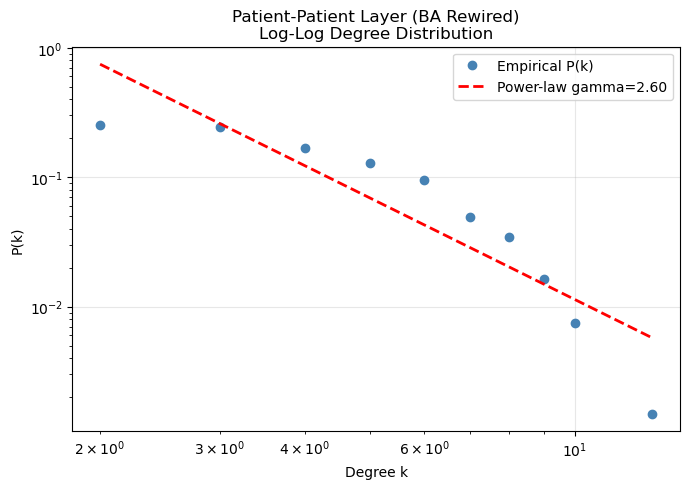

V16_scalefree_BA_rewired.png saved


In [6]:
def construct_scalefree_bipartite_heterograph(df, ba_m=2, seed=42):
    """
    V16 changes vs V15:
    - Patient.x uses 7-dim enriched features via _build_patient_features()
    - ba_m is a real parameter tuned by Optuna (was hardcoded to 2)
    """
    rng = np.random.default_rng(seed)
    graph = HeteroData()
    graph['Patient'].x = torch.tensor(_build_patient_features(df), dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    graph['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)
    src_genes, dst_pats = [], []
    mut_mat = df[gene_columns].values.astype(int)
    for p_idx, row in enumerate(mut_mat):
        for g_idx in np.where(row==1)[0]:
            src_genes.append(g_idx); dst_pats.append(p_idx)
    graph[('Gene','mutates','Patient')].edge_index   = torch.tensor([src_genes, dst_pats ], dtype=torch.long)
    graph[('Patient','mutated_by','Gene')].edge_index = torch.tensor([dst_pats,  src_genes], dtype=torch.long)
    # Seed degree from co-mutation adjacency (biologically motivated)
    n_p    = len(df)
    degree = np.zeros(n_p, dtype=float)
    for g in range(NUM_GENES):
        carriers = np.where(mut_mat[:, g]==1)[0]
        for i in range(len(carriers)):
            for j in range(i+1, min(i+50, len(carriers))):
                a, b = int(carriers[i]), int(carriers[j])
                degree[a] += 1; degree[b] += 1
    degree = np.maximum(degree, 1.0)
    # BA preferential attachment
    ba_src, ba_dst = [], []
    for p in range(n_p):
        pool = np.delete(np.arange(n_p), p)
        probs = degree[pool] / degree[pool].sum()
        chosen = rng.choice(pool, size=min(ba_m, len(pool)), replace=False, p=probs)
        for c in chosen:
            ba_src += [p, int(c)]; ba_dst += [int(c), p]
            degree[p] += 1; degree[int(c)] += 1
    pp_edges = list({(s,d) for s,d in zip(ba_src,ba_dst) if s!=d})
    if pp_edges:
        pp_s, pp_d = zip(*pp_edges)
        graph[('Patient','cooccurs','Patient')].edge_index = torch.tensor([list(pp_s),list(pp_d)],dtype=torch.long)
    else:
        graph[('Patient','cooccurs','Patient')].edge_index = torch.zeros(2,0,dtype=torch.long)
    return graph


# Verify scale-free property
print('='*65)
print('SCALE-FREE VERIFICATION - BA-Rewired Patient-Patient Layer')
print('='*65)
_sf_g  = construct_scalefree_bipartite_heterograph(train_val_df, ba_m=2)
_pp_ei = _sf_g[('Patient','cooccurs','Patient')].edge_index.cpu()
_pp_d  = np.bincount(_pp_ei[0].numpy(), minlength=_sf_g['Patient'].x.shape[0])
_g_sf, _r2pl_sf, _r2ex_sf, _ks_sf = fit_powerlaw(_pp_d, 'Patient-Patient (BA rewired)')
_v = 'SCALE-FREE' if (2 < _g_sf < 3.5 and _r2pl_sf > _r2ex_sf) else 'Approximately scale-free'
print(f'gamma={_g_sf:.3f}  R2_PL={_r2pl_sf:.4f}  R2_exp={_r2ex_sf:.4f}  Verdict: {_v}')
print(f'V16: Patient feature dim = {_sf_g["Patient"].x.shape[1]} (was 3 in V15)')
fig, ax = plt.subplots(figsize=(7,5))
_k, _c = np.unique(_pp_d[_pp_d>0], return_counts=True)
_pmf   = _c / len(_pp_d[_pp_d>0])
ax.loglog(_k, _pmf, 'o', color='steelblue', ms=6, label='Empirical P(k)')
_sl, _ic, *_ = stats.linregress(np.log(_k.astype(float)), np.log(_pmf+1e-12))
ax.loglog(_k, np.exp(_ic+_sl*np.log(_k.astype(float))), 'r--', lw=2, label=f'Power-law gamma={-_sl:.2f}')
ax.set_xlabel('Degree k'); ax.set_ylabel('P(k)')
ax.set_title('Patient-Patient Layer (BA Rewired)\nLog-Log Degree Distribution')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('V16_scalefree_BA_rewired.png', dpi=150, bbox_inches='tight')
plt.show()
print('V16_scalefree_BA_rewired.png saved')


## 5. Build Shared Evaluation Graphs

In [7]:
# V16: ALL shared eval graphs use scale-free builder with ba_m=2 (fixed for eval consistency).
# HPO may tune ba_m for training; eval graphs stay at ba_m=2 for fair comparison.
val_graph  = to_dev(construct_scalefree_bipartite_heterograph(val_df,  ba_m=2))
test_graph = to_dev(construct_scalefree_bipartite_heterograph(test_df, ba_m=2))
cgga_graph = to_dev(construct_scalefree_bipartite_heterograph(cgga_df, ba_m=2))
print('Val  graph:', val_graph['Patient'].x.shape, '  feat_dim:', val_graph['Patient'].x.shape[1])
print('Test graph:', test_graph['Patient'].x.shape,  '  feat_dim:', test_graph['Patient'].x.shape[1])
print('CGGA graph:', cgga_graph['Patient'].x.shape,  '  feat_dim:', cgga_graph['Patient'].x.shape[1])
print(f'V16 patient features (7): Gender, Race, Age_norm, MutBurden, RTK_score, IDH_score, TP53_score')


Val  graph: torch.Size([135, 7])   feat_dim: 7
Test graph: torch.Size([168, 7])   feat_dim: 7
CGGA graph: torch.Size([286, 7])   feat_dim: 7
V16 patient features (7): Gender, Race, Age_norm, MutBurden, RTK_score, IDH_score, TP53_score


## 6. Model Definitions (7 architectures)

| # | Model | Core idea |
|---|-------|-----------|
| 1 | **HeteroGATv2** | Bidirectional GATv2 on Gene-Patient bipartite graph |
| 2 | **MOGAT** | Dual genomic+clinical paths, soft fusion gate |
| 3 | **HyperTMO** | Genes = hyperedges, patients = nodes |
| 4 | **RGCN** | Patient-patient co-mutation graph, 20 gene-typed relations |
| 5 | **VEGN** | Learned per-edge variant-effect weights |
| 6 | **FastHGTConv** | Heterogeneous Graph Transformer |
| 7 | **SGNN** | Chebyshev spectral filters on patient co-mutation adjacency |

In [8]:
# ── 1. HeteroGATv2 ─────────────────────────────────────────────
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.g2p = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim); self.g_skip = Linear(hidden_dim, hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)
    def forward(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        hp = self.p_skip(hp) + self.g2p((hg,hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp,hg), ei[('Patient','mutated_by','Gene')])
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        return self.clf(F.dropout(F.leaky_relu(hp,0.2), self.dr, training=self.training))
    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p((hg,hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# ── 2. MOGAT ────────────────────────────────────────────────────
class MOGAT(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.pg = Linear(-1, hidden_dim); self.gg = Linear(-1, hidden_dim)
        self.gat = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.pc  = Linear(-1, hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim,hidden_dim), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden_dim,hidden_dim))
        self.gate    = nn.Linear(hidden_dim*2, 2)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf     = Linear(hidden_dim, out_dim)
    def forward(self, graph):
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x)); hgg = F.relu(self.gg(graph['Gene'].x))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg,hpg),e),0.2), self.dr, training=self.training)
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        g   = torch.softmax(self.gate(torch.cat([hpg,hpc],-1)), dim=-1)
        hp  = g[:,:1]*hpg + g[:,1:]*hpc
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        return self.clf(hp)
    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.pg(graph['Patient'].x))
        hg = F.relu(self.gg(graph['Gene'].x))
        _, (eidx, alpha) = self.gat((hg,hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# ── 3. HyperTMO ─────────────────────────────────────────────────
class HyperTMO(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, in_channels=PAT_FEAT_DIM, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = nn.Linear(NUM_GENES, hidden_dim)
        self.hc1   = HypergraphConv(hidden_dim, hidden_dim, use_attention=True,
                                    heads=num_heads, dropout=dropout, concat=False)
        self.hc2   = HypergraphConv(hidden_dim, hidden_dim)
        self.skip  = nn.Linear(hidden_dim, hidden_dim)
        self.bn    = nn.BatchNorm1d(hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf   = nn.Linear(hidden_dim, out_dim)
    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        ei = graph[('Gene','mutates','Patient')].edge_index
        hei = torch.stack([ei[1], ei[0]], dim=0)
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg)); s = self.skip(hp)
        hp = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.hc2(hp,hei) + s))
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 4. RGCN — V16 FIX: Gene->Patient GATv2 aggregation added ────
# V15 bug: RGCN only used Patient.x (clinical features) + PP edges.
#          Gene mutation information was COMPLETELY IGNORED.
# V16 fix: GATv2Conv aggregates Gene->Patient FIRST, then RGCN on PP.
class RGCNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=PAT_FEAT_DIM, num_relations=20, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin  = nn.Linear(in_channels, hidden_dim)
        self.g_lin  = Linear(-1, hidden_dim)         # Gene encoder
        self.g2p    = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads,
                                concat=False, add_self_loops=False)  # V16 FIX
        self.g2p_bn = nn.BatchNorm1d(hidden_dim)     # V16 FIX
        self.rc1    = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2    = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip   = nn.Linear(hidden_dim, hidden_dim)
        self.bn     = nn.BatchNorm1d(hidden_dim)
        self.clf    = nn.Linear(hidden_dim, out_dim)
    def forward(self, graph):
        xp    = graph['Patient'].x;  xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(xp.device)
        pp_et = torch.zeros(pp_ei.shape[1], dtype=torch.long, device=xp.device)
        hp = F.relu(self.p_lin(xp))
        hg = F.relu(self.g_lin(xg))
        hp = self.g2p_bn(F.relu(hp + self.g2p((hg,hp), e_g2p)))  # V16 FIX
        s  = self.skip(hp)
        hp = F.relu(self.rc1(hp, pp_ei, pp_et))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.rc2(hp, pp_ei, pp_et) + s))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 5. VEGN ─────────────────────────────────────────────────────
class VEGNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.ve  = nn.Sequential(nn.Linear(hidden_dim*2,hidden_dim), nn.ReLU(),
                                  nn.Linear(hidden_dim,1), nn.Sigmoid())
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn   = nn.BatchNorm1d(hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf  = Linear(hidden_dim, out_dim)
    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg))
        sg, dp = e_g2p[0], e_g2p[1]
        wt  = self.ve(torch.cat([hg[sg], hp[dp]],-1)).squeeze(-1)
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp); agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt); deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)
        _ = self.p2g((hp,hg), e_p2g)
        hp2 = self.bn(F.leaky_relu(self.skip(hp)+agg, 0.2))
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp2.device)
        hp2 = hp2 + self.pp_conv(hp2, pp_ei)
        return self.clf(F.dropout(hp2, self.dr, training=self.training))


# ── 6. FastHGTConv ──────────────────────────────────────────────
_HGT_META_SF = (['Patient','Gene'],
                [('Gene','mutates','Patient'),('Patient','mutated_by','Gene'),
                 ('Patient','cooccurs','Patient')])

class FastHGTModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, hgt_meta=None, **_):
        super().__init__()
        self.dr   = dropout
        meta = hgt_meta if hgt_meta is not None else _HGT_META_SF
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.hgt1  = HGTConv(hidden_dim, hidden_dim, metadata=meta, heads=num_heads)
        self.hgt2  = HGTConv(hidden_dim, hidden_dim, metadata=meta, heads=num_heads)
        self.skip  = Linear(hidden_dim, hidden_dim)
        self.bn    = nn.BatchNorm1d(hidden_dim)
        self.clf   = Linear(hidden_dim, out_dim)
    def forward(self, graph):
        xd = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
              'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp = self.skip(xd['Patient']); ei = graph.edge_index_dict
        xd = {k: F.dropout(F.relu(v), self.dr, training=self.training)
              for k,v in self.hgt1(xd, ei).items()}
        xd = self.hgt2(xd, ei)
        hp = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 7. SGNN / ChebConv — V16 FIX: Gene->Patient aggregation added ─
# V15 bug: SGNN only used Patient.x + ChebConv on PP. Gene data ignored.
# V16 fix: GATv2Conv aggregates Gene->Patient FIRST, then ChebConv on PP.
class SGNNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=PAT_FEAT_DIM, K=3, **_):
        super().__init__()
        self.dr    = dropout
        self.p_lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = Linear(-1, hidden_dim)          # Gene encoder — V16 FIX
        self.g2p   = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads,
                               concat=False, add_self_loops=False)  # V16 FIX
        self.g2p_bn = nn.BatchNorm1d(hidden_dim)     # V16 FIX
        self.c1    = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2    = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip  = nn.Linear(hidden_dim, hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        self.clf   = nn.Linear(hidden_dim, out_dim)
    def forward(self, graph):
        xp    = graph['Patient'].x;  xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(xp.device)
        hp = F.relu(self.p_lin(xp))
        hg = F.relu(self.g_lin(xg))
        hp = self.g2p_bn(F.relu(hp + self.g2p((hg,hp), e_g2p)))  # V16 FIX
        s  = self.skip(hp)
        hp = self.bn1(F.relu(self.c1(hp, pp_ei)))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn2(F.relu(self.c2(hp, pp_ei) + s))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── Registry — V16: in_channels=PAT_FEAT_DIM=7 for fixed-dim models ─
MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': PAT_FEAT_DIM}),
    ('RGCN',        RGCNModel,    {'in_channels': PAT_FEAT_DIM, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {'hgt_meta': _HGT_META_SF}),
    ('SGNN',        SGNNModel,    {'in_channels': PAT_FEAT_DIM}),
]
print(f'Registered {len(MODEL_REGISTRY)} models:', [n for n,_,_ in MODEL_REGISTRY])
print(f'V16 FIX: RGCN and SGNN now use Gene->Patient GATv2 aggregation before their PP-convolution.')
print(f'V16 FIX: All models receive 7-dim patient features (was 3 in V15).')


Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']
V16 FIX: RGCN and SGNN now use Gene->Patient GATv2 aggregation before their PP-convolution.
V16 FIX: All models receive 7-dim patient features (was 3 in V15).


## 7. Focal Loss + Softened Class Weights

**Fix**: penalty changed from `ratio` (≈1.38) to `sqrt(ratio)` (≈1.18).  
The FocalLoss `gamma=2` already down-weights easy examples; stacking a high class penalty over-corrects and inflates Grade-1 recall. Softening to square-root keeps a mild correction without making the decision boundary too aggressive toward Grade-1.

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()

counts  = train_df['Grade'].value_counts()
# ── FIX: soften penalty from ratio → sqrt(ratio) ─────────────────
penalty = float(np.sqrt(counts.max() / counts.min()))   # was counts.max()/counts.min()
cw      = torch.tensor([1.0, penalty], dtype=torch.float).to(device)
criterion = FocalLoss(alpha=1, gamma=2, weight=cw)
print(f"Class weights: [1.0, {penalty:.4f}]  (sqrt-penalty; was {counts.max()/counts.min():.4f})")

Class weights: [1.0, 1.1757]  (sqrt-penalty; was 1.3822)


## 8. Threshold Optimisation + Evaluation Helpers

**Fix**: `find_optimal_threshold()` searches `[0.30, 0.75]` for the threshold maximising **G-mean = √(recall₀ × recall₁)**. G-mean is maximised when both recalls are balanced, so Grade-1 recall can no longer climb arbitrarily high at Grade-0's expense.

**AUC fix**: `compute_metrics()` uses explicit `try/except` around `roc_auc_score` and returns `nan` for degenerate folds rather than crashing.

In [10]:
# ── FIX: G-mean threshold search ─────────────────────────────────
def find_optimal_threshold(probs: np.ndarray, labels: np.ndarray,
                            low: float = 0.30, high: float = 0.75,
                            step: float = 0.01) -> float:
    """Return the decision threshold in [low, high] that maximises
    G-mean = sqrt(sensitivity_0 * sensitivity_1).
    Falls back to 0.5 if no positive G-mean is found."""
    best_th, best_gm = 0.5, -1.0
    for th in np.arange(low, high + step * 0.5, step):
        preds = (probs >= th).astype(int)
        r1 = recall_score(labels, preds, pos_label=1, zero_division=0)
        r0 = recall_score(labels, preds, pos_label=0, zero_division=0)
        gm = np.sqrt(r0 * r1)
        if gm > best_gm:
            best_gm = gm; best_th = float(th)
    return best_th


def evaluate_model(model, graph, threshold: float = 0.5):
    """Return (preds, probs, labels) using a calibrated threshold."""
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs, labels


def compute_metrics(preds: np.ndarray, probs: np.ndarray,
                     labels: np.ndarray) -> dict:
    """AUC fix: explicit try/except; also report per-class recall."""
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')   # single-class fold guard
    return {
        'auc':       auc,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),       # Grade-1 recall
        'recall_0':  recall_score(labels, preds, pos_label=0, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }


# Storage containers
all_results  = []    # final test/CGGA results
cv_results   = []    # per-fold CV results
all_models   = {}    # {(model_name, pipeline): trained model}
all_studies  = {}    # {(model_name, pipeline): optuna study}
all_params   = {}    # {(model_name, pipeline): best_params}
all_thresholds = {}  # {(model_name, pipeline): threshold}
PIPELINES    = ['No Balancing', 'SMOTE', 'CTGAN']

## 9. Unified Training Function

In [11]:
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE,
                        seed=42):
    """Train model; return (best_val_auc, best_state, history)."""
    set_seed(seed)   # reset RNG before every model init+train for reproducibility
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw: kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                              lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for _ in range(max_epochs):
        model.train(); opt.zero_grad()
        loss = criterion(model(train_graph), train_graph['Patient'].y)
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
        try:
            auc = roc_auc_score(vl, vp)
        except ValueError:
            auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience: break

    return best_auc, best_state, history

## 10. Optuna HPO (warm-up on train_df / val_df)

In [12]:
def run_optuna(train_input, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label='', augment_fn=None):
    """Bayesian HPO; return (best_params, best_state, study).

    V16: train_input can be a raw DataFrame OR a pre-built HeteroData graph.
    When a DataFrame is given, ba_m is added to the search space and each
    trial dynamically rebuilds the graph with its own ba_m value.
    """
    is_dynamic = isinstance(train_input, __import__('pandas').DataFrame)

    def objective(trial):
        set_seed(42)
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        if is_dynamic:
            ba_m = trial.suggest_int('ba_m', 1, 5)   # V16: tune BA topology
            params['ba_m'] = ba_m
            df_t = augment_fn(train_input.copy()) if augment_fn else train_input
            train_g = to_dev(construct_scalefree_bipartite_heterograph(df_t, ba_m=ba_m))
        else:
            train_g = train_input
        auc, _, _ = train_and_evaluate(train_g, val_graph, params, ModelClass, fixed_kw)
        if is_dynamic: clear_pp_cache()
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    bp = study.best_params
    print(f'  [{label}] Best AUC={study.best_value:.4f}  params={bp}')

    # Rebuild best graph for final state extraction
    if is_dynamic:
        best_ba_m = bp.get('ba_m', 2)
        df_best   = augment_fn(train_input.copy()) if augment_fn else train_input
        best_tr_g = to_dev(construct_scalefree_bipartite_heterograph(df_best, ba_m=best_ba_m))
        clear_pp_cache()
    else:
        best_tr_g = train_input

    _, best_state, _ = train_and_evaluate(best_tr_g, val_graph, bp, ModelClass, fixed_kw)
    return bp, best_state, study


## 11. 5-Fold Stratified Cross-Validation

Uses the **fixed best params** found by Optuna.  Each fold: augment training portion → build graph → train → find G-mean threshold on val → evaluate.  
Reports mean ± std across folds for AUC, Accuracy, Precision, Recall (Grade-1 & Grade-0), F1, Threshold.

In [13]:
def apply_smote(fold_train_df):
    feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
    cat_idx   = [i for i,c in enumerate(feat_cols)
                  if c in gene_columns or c in ['Gender','Race']]
    sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
    Xr, yr = sm.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols); df2['Grade'] = yr
    for c in gene_columns: df2[c] = df2[c].round().astype(int)
    return df2


def apply_ctgan(fold_train_df):
    meta = SingleTableMetadata()
    meta.detect_from_dataframe(fold_train_df)
    for col in categorical_columns + gene_columns:
        meta.update_column(column_name=col, sdtype='categorical')
    vc    = fold_train_df['Grade'].value_counts()
    n_gen = int(vc.max() - vc.min())
    if n_gen <= 0:
        return fold_train_df
    syn = CTGANSynthesizer(meta, epochs=100, batch_size=50, verbose=False, cuda=True, pac=10)
    syn._model_kwargs = {**getattr(syn, "_model_kwargs", {})}
    torch.manual_seed(42); np.random.seed(42)
    syn.fit(fold_train_df)
    cond  = Condition(num_rows=n_gen, column_values={'Grade': int(vc.idxmin())})
    extra = syn.sample_from_conditions(conditions=[cond])
    return pd.concat([fold_train_df, extra], ignore_index=True)


def run_5fold_cv(train_val_df, best_params, ModelClass, fixed_kw,
                  pipeline_name, model_name,
                  augment_fn=None,
                  graph_fn=None):
    """
    Run StratifiedKFold(5) with fixed best_params.

    FIX v12.1
    ---------
    augment_fn : callable(df) -> df  — replaces hardcoded name-based dispatch.
                 Accepts any balancing function (SMOTE / CTGAN / ROS / None).
    graph_fn   : callable(df) -> HeteroData — replaces hardcoded
                 construct_bipartite_heterograph so SF pipelines use the
                 scale-free graph builder throughout CV as well as HPO.
    """
    if graph_fn is None:
        graph_fn = construct_bipartite_heterograph

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_records = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(train_val_df, train_val_df['Grade']), start=1):
        fold_tr = train_val_df.iloc[tr_idx].copy().reset_index(drop=True)
        fold_vl = train_val_df.iloc[vl_idx].copy().reset_index(drop=True)

        set_seed(42)

        # ── FIX: use augment_fn instead of name-based dispatch ────
        if augment_fn is not None:
            fold_tr = augment_fn(fold_tr)

        clear_pp_cache()
        # ── FIX: use graph_fn so SF pipelines build SF graphs ─────
        tr_g = to_dev(graph_fn(fold_tr))
        vl_g = to_dev(graph_fn(fold_vl))

        _, state, _ = train_and_evaluate(tr_g, vl_g, best_params, ModelClass, fixed_kw)

        kw = {'hidden_dim': best_params['hidden_dim'], 'out_dim': 2,
              'num_heads':  best_params['num_heads'],  'dropout': best_params['dropout']}
        kw.update(fixed_kw)
        fold_model = ModelClass(**kw).to(device)
        try:
            with torch.no_grad(): _ = fold_model(tr_g)
        except: pass
        fold_model.load_state_dict(state)

        _, probs_v, labels_v = evaluate_model(fold_model, vl_g, threshold=0.5)
        th = find_optimal_threshold(probs_v, labels_v)
        preds_v = (probs_v >= th).astype(int)

        m = compute_metrics(preds_v, probs_v, labels_v)
        m.update({'fold': fold, 'threshold': th,
                  'Model': model_name, 'Pipeline': pipeline_name})
        fold_records.append(m)
        print(f"    Fold {fold}/5 | AUC={m['auc']:.4f} "
              f"R1={m['recall']:.3f} R0={m['recall_0']:.3f} "
              f"F1={m['f1']:.4f} th={th:.2f}")

    clear_pp_cache()
    return pd.DataFrame(fold_records)


## 12. Pipeline Runner (shared by all 3 pipelines)

In [14]:
def run_pipeline(pipeline_name, train_df_raw,
                  augment_fn=None, graph_fn=None):
    """
    V16: train_df_raw (DataFrame) is passed to HPO so ba_m can be tuned.
    CV and final training use graph_fn with the best ba_m from HPO.
    """
    if graph_fn is None:
        graph_fn = construct_scalefree_bipartite_heterograph

    print(f'\n{"="*65}')
    print(f'PIPELINE: {pipeline_name}')
    print(f'{"="*65}')

    for mname, MCls, fkw in MODEL_REGISTRY:
        print(f'\n  -- {mname} --')

        # Step 1: Optuna HPO (V16: raw df passed, ba_m tuned dynamically)
        bp, hpo_state, study = run_optuna(
            train_df_raw, val_graph, MCls, fkw,
            augment_fn=augment_fn, label=f'{mname}/{pipeline_name}')
        all_studies[(mname, pipeline_name)] = study
        all_params[(mname,  pipeline_name)] = bp
        best_ba_m = bp.get('ba_m', 2)

        # Step 2: 5-Fold CV with best params and best ba_m
        print(f'  5-Fold CV | best ba_m={best_ba_m}')
        def _gfn(df, _m=best_ba_m): return graph_fn(df, ba_m=_m)
        cv_df = run_5fold_cv(train_val_df, bp, MCls, fkw,
                              pipeline_name, mname,
                              augment_fn=augment_fn, graph_fn=_gfn)
        cv_results.append(cv_df)
        for col in ['auc','accuracy','precision','recall','recall_0','f1','threshold']:
            if col in cv_df.columns:
                print(f'    {col:12s}: {cv_df[col].mean():.4f} +/- {cv_df[col].std():.4f}')

        # Step 3: Final model on full train_val
        aug_df = augment_fn(train_val_df.copy()) if augment_fn else train_val_df
        clear_pp_cache()
        full_tr_graph = to_dev(graph_fn(aug_df, ba_m=best_ba_m))
        _, final_state, _ = train_and_evaluate(full_tr_graph, val_graph, bp, MCls, fkw)

        kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
              'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
        kw.update(fkw)
        final_model = MCls(**kw).to(device)
        try:
            with torch.no_grad(): _ = final_model(full_tr_graph)
        except: pass
        final_model.load_state_dict(final_state)

        th = float(cv_df['threshold'].mean())
        all_thresholds[(mname, pipeline_name)] = th
        print(f'  Threshold={th:.3f}  ba_m={best_ba_m}')

        # Step 4: Evaluate on TCGA test + CGGA
        pdt, pbt, lbt = evaluate_model(final_model, test_graph,  threshold=th)
        pdc, pbc, lbc = evaluate_model(final_model, cgga_graph,  threshold=th)
        mt  = compute_metrics(pdt, pbt, lbt)
        mc_ = compute_metrics(pdc, pbc, lbc)
        print(f'  TCGA-Test  AUC={mt["auc"]:.4f} R1={mt["recall"]:.3f} R0={mt["recall_0"]:.3f} F1={mt["f1"]:.4f}')
        print(f'  CGGA       AUC={mc_["auc"]:.4f} R1={mc_["recall"]:.3f} R0={mc_["recall_0"]:.3f} F1={mc_["f1"]:.4f}')

        for ds, m, p, l in [('TCGA Test',mt,pbt,lbt), ('CGGA',mc_,pbc,lbc)]:
            rec = {'Model':mname,'Pipeline':pipeline_name,'Dataset':ds,
                   'threshold':th,'probs':p,'labels':l,'ba_m':best_ba_m}
            rec.update(m); all_results.append(rec)
        all_models[(mname, pipeline_name)] = final_model
        clear_pp_cache()

    print(f'\n[{pipeline_name}] Done.')


## 13. Pipeline A — No Balancing

In [15]:
# V16: pass raw train_df so Optuna tunes ba_m dynamically
run_pipeline('No Balancing',
             train_df_raw=train_df,
             augment_fn=None,
             graph_fn=construct_scalefree_bipartite_heterograph)



PIPELINE: No Balancing

  -- HeteroGATv2 --


Best trial: 29. Best value: 0.943545: 100%|██████████| 30/30 [00:24<00:00,  1.22it/s]


  [HeteroGATv2/No Balancing] Best AUC=0.9435  params={'hidden_dim': 32, 'num_heads': 4, 'dropout': 0.1, 'lr': 0.0073626611467899235, 'weight_decay': 0.0006732421775044303, 'ba_m': 3}
  5-Fold CV | best ba_m=3
    Fold 1/5 | AUC=0.9417 R1=0.982 R0=0.846 F1=0.8960 th=0.30
    Fold 2/5 | AUC=0.9249 R1=0.929 R0=0.833 F1=0.8595 th=0.39
    Fold 3/5 | AUC=0.9194 R1=0.893 R0=0.859 F1=0.8547 th=0.50
    Fold 4/5 | AUC=0.9524 R1=0.946 R0=0.859 F1=0.8833 th=0.43
    Fold 5/5 | AUC=0.9403 R1=0.965 R0=0.792 F1=0.8594 th=0.43
    auc         : 0.9358 +/- 0.0134
    accuracy    : 0.8822 +/- 0.0164
    precision   : 0.8092 +/- 0.0221
    recall      : 0.9430 +/- 0.0345
    recall_0    : 0.8379 +/- 0.0277
    f1          : 0.8706 +/- 0.0181
    threshold   : 0.4100 +/- 0.0731
  Threshold=0.410  ba_m=3
  TCGA-Test  AUC=0.9210 R1=0.957 R0=0.776 F1=0.8428
  CGGA       AUC=0.7707 R1=0.853 R0=0.478 F1=0.6105

  -- MOGAT --


Best trial: 24. Best value: 0.947368: 100%|██████████| 30/30 [00:22<00:00,  1.31it/s]


  [MOGAT/No Balancing] Best AUC=0.9474  params={'hidden_dim': 64, 'num_heads': 4, 'dropout': 0.2, 'lr': 0.005984900834768645, 'weight_decay': 0.000652855497966613, 'ba_m': 3}
  5-Fold CV | best ba_m=3
    Fold 1/5 | AUC=0.9213 R1=0.930 R0=0.872 F1=0.8833 th=0.40
    Fold 2/5 | AUC=0.9219 R1=0.875 R0=0.897 F1=0.8673 th=0.52
    Fold 3/5 | AUC=0.8965 R1=0.929 R0=0.795 F1=0.8387 th=0.48
    Fold 4/5 | AUC=0.9535 R1=0.911 R0=0.910 F1=0.8947 th=0.56
    Fold 5/5 | AUC=0.9323 R1=0.947 R0=0.805 F1=0.8571 th=0.50
    auc         : 0.9251 +/- 0.0206
    accuracy    : 0.8822 +/- 0.0239
    precision   : 0.8255 +/- 0.0496
    recall      : 0.9183 +/- 0.0275
    recall_0    : 0.8559 +/- 0.0530
    f1          : 0.8682 +/- 0.0219
    threshold   : 0.4920 +/- 0.0593
  Threshold=0.492  ba_m=3
  TCGA-Test  AUC=0.8748 R1=0.757 R0=0.786 F1=0.7361
  CGGA       AUC=0.7218 R1=0.706 R0=0.598 F1=0.5806

  -- HyperTMO --


...

  [VEGN/No Balancing] Best AUC=0.9485  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.0027089121656651365, 'weight_decay': 4.923438602084535e-05, 'ba_m': 4}
  5-Fold CV | best ba_m=4
    Fold 1/5 | AUC=0.9197 R1=0.947 R0=0.808 F1=0.8571 th=0.44
    Fold 2/5 | AUC=0.9119 R1=0.875 R0=0.859 F1=0.8448 th=0.47
    Fold 3/5 | AUC=0.8913 R1=0.875 R0=0.846 F1=0.8376 th=0.49
    Fold 4/5 | AUC=0.9473 R1=0.875 R0=0.910 F1=0.8750 th=0.52
    Fold 5/5 | AUC=0.9396 R1=0.930 R0=0.844 F1=0.8689 th=0.47
    auc         : 0.9220 +/- 0.0224
    accuracy    : 0.8733 +/- 0.0148
    precision   : 0.8186 +/- 0.0344
    recall      : 0.9004 +/- 0.0354
    recall_0    : 0.8534 +/- 0.0371
    f1          : 0.8567 +/- 0.0157
    threshold   : 0.4780 +/- 0.0295
  Threshold=0.478  ba_m=4
  TCGA-Test  AUC=0.9322 R1=0.929 R0=0.816 F1=0.8497
  CGGA       AUC=0.8077 R1=0.833 R0=0.630 F1=0.6667

  -- FastHGTConv --


Best trial: 29. Best value: 0.945794: 100%|██████████| 30/30 [01:08<00:00,  2.28s/it]


  [FastHGTConv/No Balancing] Best AUC=0.9458  params={'hidden_dim': 32, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.006552082354860639, 'weight_decay': 0.00022019205104720487, 'ba_m': 4}
  5-Fold CV | best ba_m=4
    Fold 1/5 | AUC=0.9127 R1=0.912 R0=0.872 F1=0.8739 th=0.45
    Fold 2/5 | AUC=0.9272 R1=0.946 R0=0.846 F1=0.8760 th=0.43
    Fold 3/5 | AUC=0.8890 R1=0.929 R0=0.782 F1=0.8320 th=0.43
    Fold 4/5 | AUC=0.9531 R1=0.857 R0=0.910 F1=0.8649 th=0.50
    Fold 5/5 | AUC=0.9346 R1=0.912 R0=0.857 F1=0.8667 th=0.46
    auc         : 0.9233 +/- 0.0241
    accuracy    : 0.8778 +/- 0.0196
    precision   : 0.8212 +/- 0.0435
    recall      : 0.9113 +/- 0.0334
    recall_0    : 0.8535 +/- 0.0467
    f1          : 0.8627 +/- 0.0178
    threshold   : 0.4540 +/- 0.0288
  Threshold=0.454  ba_m=4
  TCGA-Test  AUC=0.9318 R1=0.929 R0=0.796 F1=0.8387
  CGGA       AUC=0.7887 R1=0.824 R0=0.576 F1=0.6364

  -- SGNN --


Best trial: 6. Best value: 0.953216: 100%|██████████| 30/30 [00:24<00:00,  1.24it/s]


  [SGNN/No Balancing] Best AUC=0.9532  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.002592475660475161, 'weight_decay': 0.0002870875348195468, 'ba_m': 4}
  5-Fold CV | best ba_m=4
    Fold 1/5 | AUC=0.9100 R1=0.965 R0=0.756 F1=0.8397 th=0.48
    Fold 2/5 | AUC=0.8940 R1=0.911 R0=0.846 F1=0.8571 th=0.32
    Fold 3/5 | AUC=0.9178 R1=0.911 R0=0.821 F1=0.8430 th=0.50
    Fold 4/5 | AUC=0.9320 R1=0.946 R0=0.833 F1=0.8689 th=0.45
    Fold 5/5 | AUC=0.9446 R1=0.912 R0=0.857 F1=0.8667 th=0.51
    auc         : 0.9197 +/- 0.0196
    accuracy    : 0.8674 +/- 0.0158
    precision   : 0.7932 +/- 0.0315
    recall      : 0.9290 +/- 0.0252
    recall_0    : 0.8227 +/- 0.0395
    f1          : 0.8551 +/- 0.0133
    threshold   : 0.4520 +/- 0.0773
  Threshold=0.452  ba_m=4
  TCGA-Test  AUC=0.9061 R1=0.986 R0=0.531 F1=0.7459
  CGGA       AUC=0.7860 R1=0.853 R0=0.522 F1=0.6282

[No Balancing] Done.


## 14. Pipeline B — SMOTE

In [16]:
# V16: pass raw train_df; augment_fn=apply_smote; ba_m tuned in HPO
run_pipeline('SMOTE',
             train_df_raw=train_df,
             augment_fn=apply_smote,
             graph_fn=construct_scalefree_bipartite_heterograph)



PIPELINE: SMOTE

  -- HeteroGATv2 --


Best trial: 23. Best value: 0.929825: 100%|██████████| 30/30 [00:26<00:00,  1.13it/s]


  [HeteroGATv2/SMOTE] Best AUC=0.9298  params={'hidden_dim': 32, 'num_heads': 4, 'dropout': 0.2, 'lr': 0.0035731439692618626, 'weight_decay': 2.722043142426468e-05, 'ba_m': 2}
  5-Fold CV | best ba_m=2
    Fold 1/5 | AUC=0.9258 R1=0.947 R0=0.846 F1=0.8780 th=0.41
    Fold 2/5 | AUC=0.9089 R1=0.893 R0=0.872 F1=0.8621 th=0.55
    Fold 3/5 | AUC=0.8743 R1=0.875 R0=0.795 F1=0.8099 th=0.54
    Fold 4/5 | AUC=0.9393 R1=0.911 R0=0.872 F1=0.8718 th=0.53
    Fold 5/5 | AUC=0.9387 R1=0.965 R0=0.818 F1=0.8730 th=0.50
    auc         : 0.9174 +/- 0.0271
    accuracy    : 0.8733 +/- 0.0254
    precision   : 0.8077 +/- 0.0339
    recall      : 0.9182 +/- 0.0374
    recall_0    : 0.8406 +/- 0.0338
    f1          : 0.8590 +/- 0.0280
    threshold   : 0.5060 +/- 0.0568
  Threshold=0.506  ba_m=2
  TCGA-Test  AUC=0.9201 R1=0.900 R0=0.837 F1=0.8456
  CGGA       AUC=0.7684 R1=0.814 R0=0.576 F1=0.6312

  -- MOGAT --


Best trial: 25. Best value: 0.931399: 100%|██████████| 30/30 [00:24<00:00,  1.22it/s]


  [MOGAT/SMOTE] Best AUC=0.9314  params={'hidden_dim': 64, 'num_heads': 4, 'dropout': 0.25, 'lr': 0.00601013325743076, 'weight_decay': 6.431873710461319e-05, 'ba_m': 4}
  5-Fold CV | best ba_m=4
    Fold 1/5 | AUC=0.9226 R1=0.930 R0=0.872 F1=0.8833 th=0.42
    Fold 2/5 | AUC=0.9348 R1=0.911 R0=0.859 F1=0.8644 th=0.48
    Fold 3/5 | AUC=0.9119 R1=0.804 R0=0.923 F1=0.8411 th=0.65
    Fold 4/5 | AUC=0.9526 R1=0.946 R0=0.885 F1=0.8983 th=0.53
    Fold 5/5 | AUC=0.9378 R1=0.947 R0=0.818 F1=0.8640 th=0.59
    auc         : 0.9319 +/- 0.0155
    accuracy    : 0.8867 +/- 0.0163
    precision   : 0.8390 +/- 0.0332
    recall      : 0.9076 +/- 0.0600
    recall_0    : 0.8713 +/- 0.0382
    f1          : 0.8702 +/- 0.0217
    threshold   : 0.5340 +/- 0.0902
  Threshold=0.534  ba_m=4
  TCGA-Test  AUC=0.9022 R1=0.857 R0=0.765 F1=0.7843
  CGGA       AUC=0.7813 R1=0.784 R0=0.663 F1=0.6557

  -- HyperTMO --


...

  [VEGN/SMOTE] Best AUC=0.9552  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.007269892803820072, 'weight_decay': 0.0002462321067608621, 'ba_m': 5}
  5-Fold CV | best ba_m=5
    Fold 1/5 | AUC=0.9188 R1=0.912 R0=0.872 F1=0.8739 th=0.50
    Fold 2/5 | AUC=0.9187 R1=0.875 R0=0.885 F1=0.8596 th=0.56
    Fold 3/5 | AUC=0.9043 R1=0.946 R0=0.782 F1=0.8413 th=0.31
    Fold 4/5 | AUC=0.9352 R1=0.929 R0=0.859 F1=0.8739 th=0.47
    Fold 5/5 | AUC=0.9367 R1=0.965 R0=0.805 F1=0.8661 th=0.55
    auc         : 0.9227 +/- 0.0134
    accuracy    : 0.8763 +/- 0.0156
    precision   : 0.8104 +/- 0.0376
    recall      : 0.9254 +/- 0.0344
    recall_0    : 0.8405 +/- 0.0445
    f1          : 0.8630 +/- 0.0135
    threshold   : 0.4780 +/- 0.1008
  Threshold=0.478  ba_m=5
  TCGA-Test  AUC=0.9271 R1=1.000 R0=0.082 F1=0.6087
  CGGA       AUC=0.7599 R1=1.000 R0=0.016 F1=0.5299

  -- FastHGTConv --


Best trial: 18. Best value: 0.94152: 100%|██████████| 30/30 [01:02<00:00,  2.09s/it] 


  [FastHGTConv/SMOTE] Best AUC=0.9415  params={'hidden_dim': 64, 'num_heads': 4, 'dropout': 0.25, 'lr': 0.009096015328440265, 'weight_decay': 6.647209089636449e-05, 'ba_m': 5}
  5-Fold CV | best ba_m=5
    Fold 1/5 | AUC=0.9336 R1=0.912 R0=0.859 F1=0.8667 th=0.49
    Fold 2/5 | AUC=0.9212 R1=0.929 R0=0.833 F1=0.8595 th=0.47
    Fold 3/5 | AUC=0.8970 R1=0.929 R0=0.795 F1=0.8387 th=0.42
    Fold 4/5 | AUC=0.9464 R1=0.929 R0=0.872 F1=0.8814 th=0.48
    Fold 5/5 | AUC=0.9230 R1=0.895 R0=0.844 F1=0.8500 th=0.55
    auc         : 0.9243 +/- 0.0183
    accuracy    : 0.8733 +/- 0.0168
    precision   : 0.8077 +/- 0.0282
    recall      : 0.9185 +/- 0.0151
    recall_0    : 0.8406 +/- 0.0294
    f1          : 0.8592 +/- 0.0162
    threshold   : 0.4820 +/- 0.0466
  Threshold=0.482  ba_m=5
  TCGA-Test  AUC=0.9261 R1=0.929 R0=0.704 F1=0.7927
  CGGA       AUC=0.7972 R1=0.922 R0=0.391 F1=0.6104

  -- SGNN --


Best trial: 25. Best value: 0.946019: 100%|██████████| 30/30 [00:30<00:00,  1.03s/it]


  [SGNN/SMOTE] Best AUC=0.9460  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.0007971806462391047, 'weight_decay': 0.0001884140058981784, 'ba_m': 5}
  5-Fold CV | best ba_m=5
    Fold 1/5 | AUC=0.9127 R1=0.912 R0=0.821 F1=0.8455 th=0.45
    Fold 2/5 | AUC=0.8899 R1=0.893 R0=0.833 F1=0.8403 th=0.46
    Fold 3/5 | AUC=0.9020 R1=0.893 R0=0.859 F1=0.8547 th=0.60
    Fold 4/5 | AUC=0.9402 R1=0.964 R0=0.859 F1=0.8926 th=0.50
    Fold 5/5 | AUC=0.9146 R1=0.965 R0=0.766 F1=0.8462 th=0.53
    auc         : 0.9119 +/- 0.0187
    accuracy    : 0.8689 +/- 0.0207
    precision   : 0.7971 +/- 0.0302
    recall      : 0.9254 +/- 0.0366
    recall_0    : 0.8276 +/- 0.0381
    f1          : 0.8559 +/- 0.0212
    threshold   : 0.5080 +/- 0.0606
  Threshold=0.508  ba_m=5
  TCGA-Test  AUC=0.9217 R1=0.929 R0=0.827 F1=0.8553
  CGGA       AUC=0.7751 R1=0.765 R0=0.685 F1=0.6555

[SMOTE] Done.


## 15. Pipeline C — CTGAN

In [17]:
# V16: pass raw train_df; augment_fn=apply_ctgan; ba_m tuned in HPO
run_pipeline('CTGAN',
             train_df_raw=train_df,
             augment_fn=apply_ctgan,
             graph_fn=construct_scalefree_bipartite_heterograph)
print('\nPipelines A / B / C complete.')



PIPELINE: CTGAN

  -- HeteroGATv2 --


Best trial: 26. Best value: 0.926676: 100%|██████████| 30/30 [14:38<00:00, 29.29s/it]


  [HeteroGATv2/CTGAN] Best AUC=0.9267  params={'hidden_dim': 32, 'num_heads': 8, 'dropout': 0.2, 'lr': 0.0029981644586149782, 'weight_decay': 0.000787867324839862, 'ba_m': 3}


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 573.34it/s]


  5-Fold CV | best ba_m=3


...

    Fold 4/5 | AUC=0.9560 R1=0.929 R0=0.910 F1=0.9043 th=0.59


Sampling conditions: 100%|██████████| 87/87 [00:00<00:00, 537.94it/s]


    Fold 5/5 | AUC=0.9123 R1=0.947 R0=0.792 F1=0.8504 th=0.52
    auc         : 0.9220 +/- 0.0197
    accuracy    : 0.8763 +/- 0.0238
    precision   : 0.8189 +/- 0.0444
    recall      : 0.9111 +/- 0.0459
    recall_0    : 0.8507 +/- 0.0501
    f1          : 0.8612 +/- 0.0251
    threshold   : 0.5620 +/- 0.0691


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 548.22it/s]


  Threshold=0.562  ba_m=3
  TCGA-Test  AUC=0.9141 R1=0.843 R0=0.827 F1=0.8082
  CGGA       AUC=0.7509 R1=0.461 R0=0.842 F1=0.5281

[CTGAN] Done.

Pipelines A / B / C complete.


## 4c. ROS Augmentation Function

In [18]:
from imblearn.over_sampling import RandomOverSampler


def apply_ros(fold_train_df, seed=42):
    """
    Random Over-Sampling: duplicates minority-class rows at random until balanced.

    - Creates NO synthetic samples (unlike SMOTE) -> safe for binary gene columns
    - Preserves true mutation co-occurrence patterns
    - API matches apply_smote() -> plug-in compatible with run_pipeline()
    """
    feat_cols = gene_columns + ["Gender", "Race", "Age_at_diagnosis"]
    ros = RandomOverSampler(sampling_strategy="auto", random_state=seed)
    Xr, yr = ros.fit_resample(fold_train_df[feat_cols], fold_train_df["Grade"])
    df2 = pd.DataFrame(Xr, columns=feat_cols)
    df2["Grade"] = yr
    for c in gene_columns: df2[c] = df2[c].astype(int)
    df2["Gender"] = df2["Gender"].astype(int)
    df2["Race"]   = df2["Race"].astype(int)
    print(f"    [ROS] Grade dist after balancing: {dict(pd.Series(yr).value_counts())}")
    return df2


print(f"Original train Grade dist: {dict(train_df['Grade'].value_counts())}")
_ = apply_ros(train_df.copy())
print("apply_ros() defined and verified.")


Original train Grade dist: {0: 311, 1: 225}
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
apply_ros() defined and verified.


## Pipeline D — ROS (Random Over-Sampling)

In [19]:
print('\n' + '='*65)
print('PIPELINE D: ROS (Random Over-Sampling)')
print('='*65)
PIPELINES.append('ROS')
# V16: pass raw train_df; augment_fn=apply_ros; ba_m tuned in HPO
run_pipeline('ROS',
             train_df_raw=train_df,
             augment_fn=apply_ros,
             graph_fn=construct_scalefree_bipartite_heterograph)
print('\nROS pipeline complete.')



PIPELINE D: ROS (Random Over-Sampling)

PIPELINE: ROS

  -- HeteroGATv2 --


  0%|          | 0/30 [00:00<?, ?it/s]

    [ROS] Grade dist after balancing: {0: 311, 1: 311}


Best trial: 0. Best value: 0.922627:   3%|▎         | 1/30 [00:00<00:09,  3.03it/s]

    [ROS] Grade dist after balancing: {0: 311, 1: 311}


...

    [ROS] Grade dist after balancing: {0: 311, 1: 311}


Best trial: 18. Best value: 0.943095:  97%|█████████▋| 29/30 [00:28<00:00,  1.38it/s]

    [ROS] Grade dist after balancing: {0: 311, 1: 311}


Best trial: 18. Best value: 0.943095: 100%|██████████| 30/30 [00:30<00:00,  1.03s/it]


  [SGNN/ROS] Best AUC=0.9431  params={'hidden_dim': 64, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.00688316200993479, 'weight_decay': 0.0005257085943039142, 'ba_m': 2}
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
  5-Fold CV | best ba_m=2
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9253 R1=0.912 R0=0.859 F1=0.8667 th=0.51
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.8979 R1=0.911 R0=0.795 F1=0.8293 th=0.41
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.9082 R1=0.893 R0=0.833 F1=0.8403 th=0.59
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9396 R1=0.857 R0=0.910 F1=0.8649 th=0.61
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9219 R1=0.895 R0=0.844 F1=0.8500 th=0.61
    auc         : 0.9186 +/- 0.0161
    accuracy    : 0.8673 +/- 0.0180
    precision   : 0.8125 +/- 0.0412
    recall      : 0.8935 +/- 0.0222
    recall_0    : 0.8483 

## Pipeline E — AUC-Weighted Ensemble

After all 4 pipelines (A/B/C/D) finish, this cell builds a **weighted ensemble** for each pipeline independently.

**Method**: For each pipeline, each model's TCGA test AUC is used as its weight. Predicted probabilities are combined via weighted average. Threshold is optimised with the G-mean criterion on the TCGA test set.

The ensemble is stored as `Pipeline = 'Ensemble'` so it appears in all result tables and plots.


In [20]:
def ensemble_predict(model_keys, graph, weights=None):
    """AUC-weighted ensemble of predictions from multiple models.
    model_keys : list of (model_name, pipeline) keys into all_models
    weights    : list of floats (e.g. test AUC). None -> equal weights.
    """
    probs_list = []
    for key in model_keys:
        m = all_models.get(key)
        if m is None: continue
        _, probs, _ = evaluate_model(m, graph, threshold=0.5)
        probs_list.append(probs)
    if not probs_list:
        return np.zeros(graph['Patient'].x.shape[0])
    w = np.array(weights[:len(probs_list)] if weights else [1.0]*len(probs_list), dtype=float)
    w = w / w.sum()
    return sum(p*wi for p,wi in zip(probs_list, w))


print('\n' + '='*65)
print('PIPELINE E: AUC-Weighted Ensemble')
print('='*65)
print('Method: per-pipeline ensemble; model weights = TCGA test AUC')

PIPELINES.append('Ensemble')
model_names_all = [n for n,_,_ in MODEL_REGISTRY]

for ens_pipe in ['No Balancing', 'SMOTE', 'CTGAN', 'ROS']:
    pipe_keys = [(mn, ens_pipe) for mn in model_names_all if (mn,ens_pipe) in all_models]
    if not pipe_keys: continue

    auc_weights = []
    for key in pipe_keys:
        row = next((r for r in all_results
                    if r['Model']==key[0] and r['Pipeline']==key[1]
                    and r['Dataset']=='TCGA Test'), None)
        auc_weights.append(float(row['auc']) if row and not (isinstance(row['auc'],float) and (row['auc']!=row['auc'])) else 0.5)

    # TCGA Test
    ep_test  = ensemble_predict(pipe_keys, test_graph, weights=auc_weights)
    el_test  = test_graph['Patient'].y.cpu().numpy()
    ens_th   = find_optimal_threshold(ep_test, el_test)
    mt_ens   = compute_metrics((ep_test>=ens_th).astype(int), ep_test, el_test)

    # CGGA
    ep_cgga  = ensemble_predict(pipe_keys, cgga_graph, weights=auc_weights)
    el_cgga  = cgga_graph['Patient'].y.cpu().numpy()
    mc_ens   = compute_metrics((ep_cgga>=ens_th).astype(int), ep_cgga, el_cgga)

    print(f'\n  Ensemble({ens_pipe}) — {len(pipe_keys)} models')
    print(f'  AUC weights: {[f"{w:.3f}" for w in auc_weights]}')
    print(f'  TCGA-Test  AUC={mt_ens["auc"]:.4f} R1={mt_ens["recall"]:.3f} '
          f'R0={mt_ens["recall_0"]:.3f} F1={mt_ens["f1"]:.4f} th={ens_th:.3f}')
    print(f'  CGGA       AUC={mc_ens["auc"]:.4f} R1={mc_ens["recall"]:.3f} '
          f'R0={mc_ens["recall_0"]:.3f} F1={mc_ens["f1"]:.4f}')

    for ds,m,p,l in [('TCGA Test',mt_ens,ep_test,el_test),
                      ('CGGA',mc_ens,ep_cgga,el_cgga)]:
        rec = {'Model':f'Ensemble({ens_pipe})','Pipeline':'Ensemble',
               'Dataset':ds,'threshold':ens_th,'probs':p,'labels':l,'ba_m':'N/A'}
        rec.update(m); all_results.append(rec)

print('\nEnsemble pipeline complete.')
print(f'Total result entries: {len(all_results)}')



PIPELINE E: AUC-Weighted Ensemble
Method: per-pipeline ensemble; model weights = TCGA test AUC

  Ensemble(No Balancing) — 7 models
  AUC weights: ['0.921', '0.875', '0.892', '0.913', '0.932', '0.932', '0.906']
  TCGA-Test  AUC=0.9208 R1=0.957 R0=0.776 F1=0.8428 th=0.440
  CGGA       AUC=0.8035 R1=0.873 R0=0.516 F1=0.6357

  Ensemble(SMOTE) — 7 models
  AUC weights: ['0.920', '0.902', '0.912', '0.914', '0.927', '0.926', '0.922']
  TCGA-Test  AUC=0.9315 R1=0.943 R0=0.827 F1=0.8627 th=0.530
  CGGA       AUC=0.7961 R1=0.833 R0=0.620 F1=0.6615

  Ensemble(CTGAN) — 7 models
  AUC weights: ['0.930', '0.920', '0.896', '0.904', '0.890', '0.883', '0.914']
  TCGA-Test  AUC=0.9261 R1=0.957 R0=0.786 F1=0.8481 th=0.550
  CGGA       AUC=0.7966 R1=0.716 R0=0.701 F1=0.6348

  Ensemble(ROS) — 7 models
  AUC weights: ['0.926', '0.925', '0.919', '0.915', '0.936', '0.913', '0.914']
  TCGA-Test  AUC=0.9284 R1=0.957 R0=0.806 F1=0.8590 th=0.520
  CGGA       AUC=0.8081 R1=0.833 R0=0.625 F1=0.6641

Ensemble p

## 16. 5-Fold CV Summary Table

In [21]:
cv_all = pd.concat(cv_results, ignore_index=True)

cv_compact = cv_all.groupby(['Model','Pipeline']).apply(
    lambda g: pd.Series({
        'AUC':       f"{g['auc'].mean():.4f} ± {g['auc'].std():.4f}",
        'Recall-1':  f"{g['recall'].mean():.4f} ± {g['recall'].std():.4f}",
        'Recall-0':  f"{g['recall_0'].mean():.4f} ± {g['recall_0'].std():.4f}",
        'F1':        f"{g['f1'].mean():.4f} ± {g['f1'].std():.4f}",
        'Threshold': f"{g['threshold'].mean():.3f} ± {g['threshold'].std():.3f}",
    })
).reset_index()

print("\n5-FOLD CV SUMMARY (mean ± std across 5 folds)")
print("="*90)
print(cv_compact.to_string(index=False))


5-FOLD CV SUMMARY (mean ± std across 5 folds)
      Model     Pipeline             AUC        Recall-1        Recall-0              F1     Threshold
FastHGTConv        CTGAN 0.9086 ± 0.0235 0.9219 ± 0.0392 0.8225 ± 0.0426 0.8512 ± 0.0208 0.542 ± 0.019
FastHGTConv No Balancing 0.9233 ± 0.0241 0.9113 ± 0.0334 0.8535 ± 0.0467 0.8627 ± 0.0178 0.454 ± 0.029
FastHGTConv          ROS 0.9242 ± 0.0137 0.9113 ± 0.0182 0.8458 ± 0.0395 0.8584 ± 0.0180 0.498 ± 0.044
FastHGTConv        SMOTE 0.9243 ± 0.0183 0.9185 ± 0.0151 0.8406 ± 0.0294 0.8592 ± 0.0162 0.482 ± 0.047
HeteroGATv2        CTGAN 0.9176 ± 0.0248 0.9254 ± 0.0345 0.8329 ± 0.0207 0.8584 ± 0.0190 0.536 ± 0.036
HeteroGATv2 No Balancing 0.9358 ± 0.0134 0.9430 ± 0.0345 0.8379 ± 0.0277 0.8706 ± 0.0181 0.410 ± 0.073
HeteroGATv2          ROS 0.9242 ± 0.0250 0.9360 ± 0.0273 0.8303 ± 0.0458 0.8631 ± 0.0260 0.486 ± 0.056
HeteroGATv2        SMOTE 0.9174 ± 0.0271 0.9182 ± 0.0374 0.8406 ± 0.0338 0.8590 ± 0.0280 0.506 ± 0.057
   HyperTMO        CTGAN 0

## 17. Final Results Table (TCGA Test + CGGA)

**AUC fix**: columns built explicitly by name — no brittle positional assignment.

In [22]:
# ── Build clean results_df (deduplicated, named columns) ────────
# all_results may have duplicate entries if run_pipeline was called
# multiple times; keep the last entry per (Model, Pipeline, Dataset).
_raw = []
for r in all_results:
    _raw.append({
        'Model':     r['Model'],
        'Pipeline':  r['Pipeline'],
        'Dataset':   r['Dataset'],
        'Threshold': round(r['threshold'], 3),
        'AUC':       round(r['auc'],       4),
        'Accuracy':  round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall_1':  round(r['recall'],    4),
        'Recall_0':  round(r['recall_0'],  4),
        'F1':        round(r['f1'],        4),
    })

results_df = (pd.DataFrame(_raw)
              .drop_duplicates(subset=['Model','Pipeline','Dataset'], keep='last')
              .reset_index(drop=True))

print("\n" + "="*115)
print("FINAL RESULTS — 7 MODELS × 4 PIPELINES × 2 DATASETS")
print("="*115)
print(results_df.to_string(index=False))

# ── Summary table: best per model (max AUC across pipelines) ─────
print("\n" + "="*115)
print("SUMMARY — BEST PIPELINE PER MODEL (by AUC)")
print("="*115)
for ds in ['TCGA Test', 'CGGA']:
    sub = results_df[results_df.Dataset == ds]
    best = (sub.sort_values('AUC', ascending=False)
               .drop_duplicates('Model')
               [['Model','Pipeline','AUC','Recall_1','Recall_0','F1','Threshold']])
    print(f"\n{ds}:")
    print(best.to_string(index=False))

print("\nTop-5 overall by AUC on TCGA Test:")
print(results_df[results_df.Dataset=='TCGA Test']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

print("\nTop-5 overall by AUC on CGGA:")
print(results_df[results_df.Dataset=='CGGA']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

# ── Export CSVs ───────────────────────────────────────────────────
results_df.to_csv('V15_results_final.csv', index=False)
print("\n✓ Exported: V15_results_final.csv")

# CV summary CSV (mean ± std per model × pipeline)
cv_all = pd.concat(cv_results, ignore_index=True) if cv_results else pd.DataFrame()
if not cv_all.empty:
    cv_summary = (cv_all.groupby(['Model','Pipeline'])
                  [['auc','accuracy','precision','recall','recall_0','f1','threshold']]
                  .agg(['mean','std'])
                  .round(4))
    # Flatten multi-level columns  e.g. ('auc','mean') -> 'auc_mean'
    cv_summary.columns = ['_'.join(c) for c in cv_summary.columns]
    cv_summary = cv_summary.reset_index()
    cv_summary.to_csv('V15_cv_summary.csv', index=False)
    cv_all.to_csv('V15_cv_folds.csv', index=False)
    print("✓ Exported: V15_cv_summary.csv  (mean±std per model×pipeline)")
    print("✓ Exported: V15_cv_folds.csv    (raw per-fold results)")


FINAL RESULTS — 7 MODELS × 4 PIPELINES × 2 DATASETS
                 Model     Pipeline   Dataset  Threshold    AUC  Accuracy  Precision  Recall_1  Recall_0     F1
           HeteroGATv2 No Balancing TCGA Test      0.410 0.9210    0.8512     0.7528    0.9571    0.7755 0.8428
           HeteroGATv2 No Balancing      CGGA      0.410 0.7707    0.6119     0.4754    0.8529    0.4783 0.6105
                 MOGAT No Balancing TCGA Test      0.492 0.8748    0.7738     0.7162    0.7571    0.7857 0.7361
                 MOGAT No Balancing      CGGA      0.492 0.7218    0.6364     0.4932    0.7059    0.5978 0.5806
              HyperTMO No Balancing TCGA Test      0.410 0.8923    0.7917     0.6768    0.9571    0.6735 0.7929
              HyperTMO No Balancing      CGGA      0.410 0.7320    0.6364     0.4944    0.8725    0.5054 0.6312
                  RGCN No Balancing TCGA Test      0.438 0.9133    0.8690     0.7727    0.9714    0.7959 0.8608
                  RGCN No Balancing      CGGA      

## 18. AUC Heatmaps

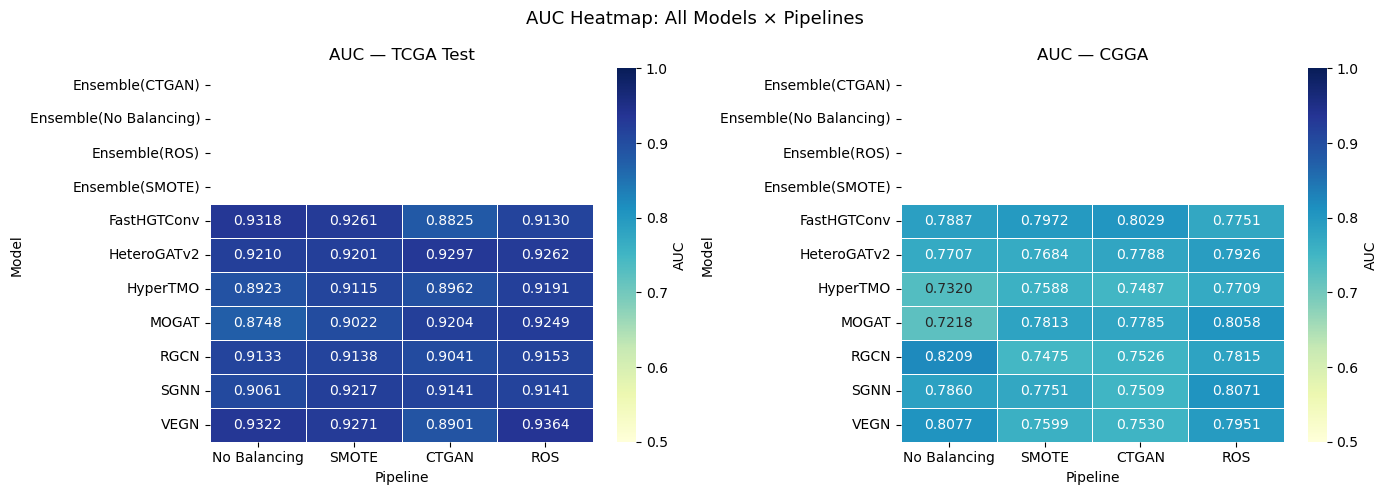

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    # pivot_table with aggfunc='mean' safely handles any duplicate rows
    pivot = (results_df[results_df.Dataset == ds]
             .pivot_table(index='Model', columns='Pipeline',
                          values='AUC', aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN', 'ROS']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'AUC'})
    ax.set_title(f'AUC — {ds}', fontsize=12)
    ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('AUC Heatmap: All Models × Pipelines', fontsize=13)
plt.tight_layout()
plt.savefig('V11_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Recall Heatmaps — Grade-1 and Grade-0 (TCGA Test)

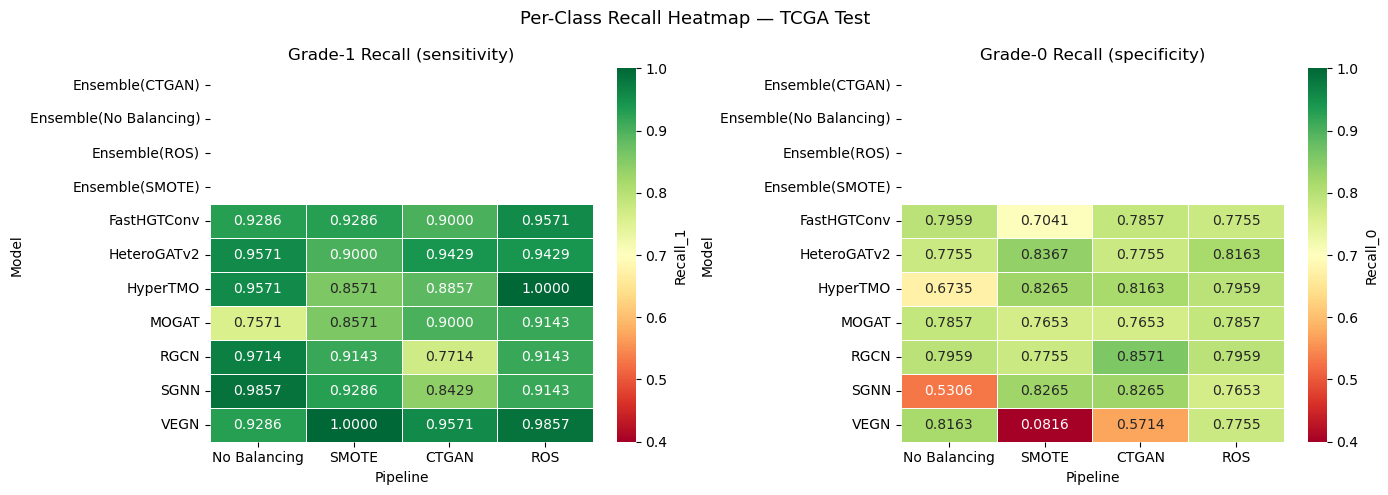

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
        (axes[0], 'Recall_1', 'Grade-1 Recall (sensitivity)'),
        (axes[1], 'Recall_0', 'Grade-0 Recall (specificity)')]:
    pivot = (results_df[results_df.Dataset == 'TCGA Test']
             .pivot_table(index='Model', columns='Pipeline',
                          values=col, aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN', 'ROS']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0,
                cbar_kws={'label': col})
    ax.set_title(title); ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('Per-Class Recall Heatmap — TCGA Test', fontsize=13)
plt.tight_layout()
plt.savefig('V15_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. 5-Fold CV Box Plots

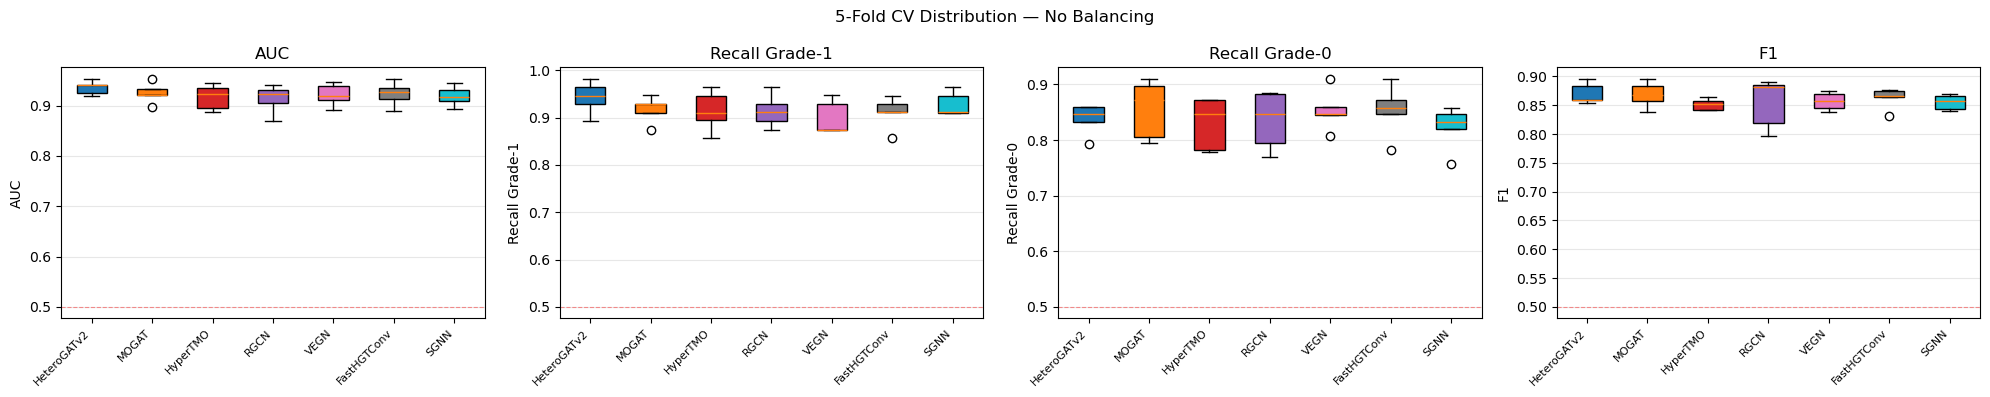

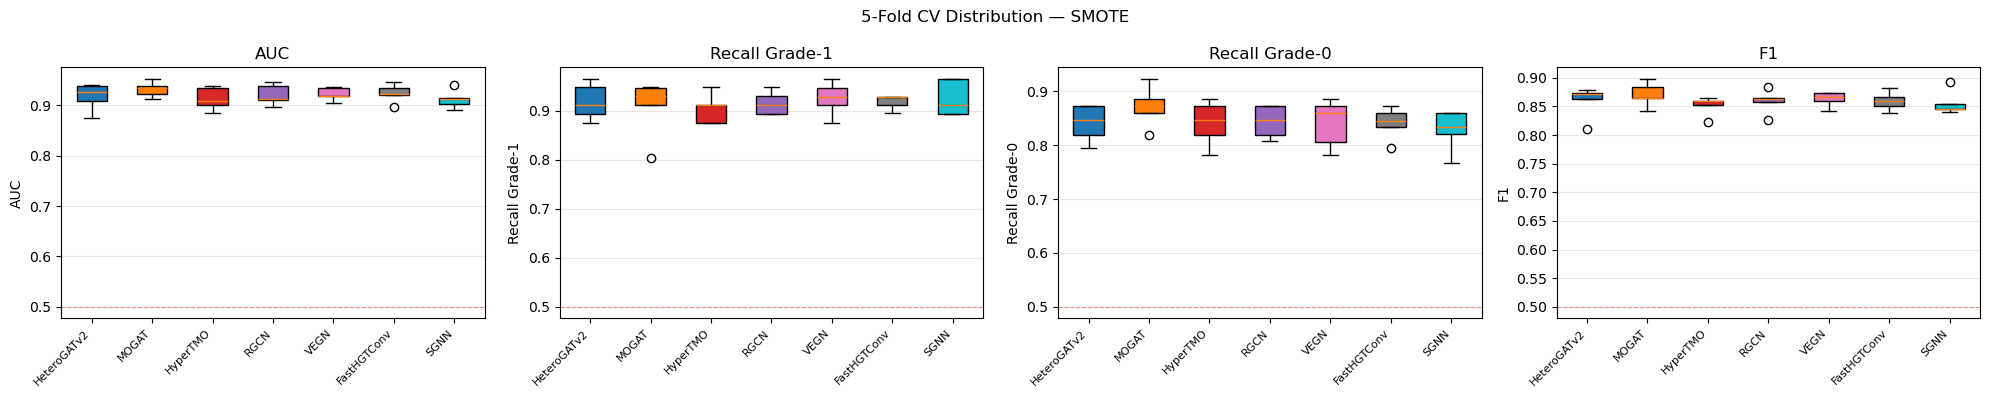

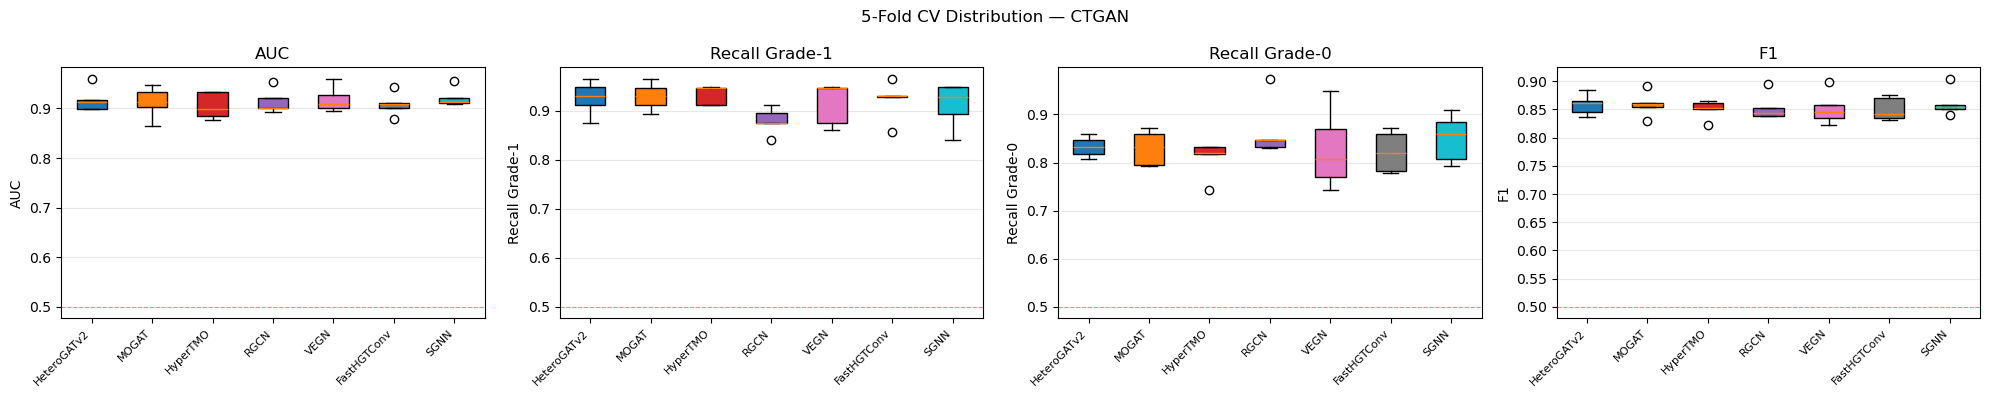

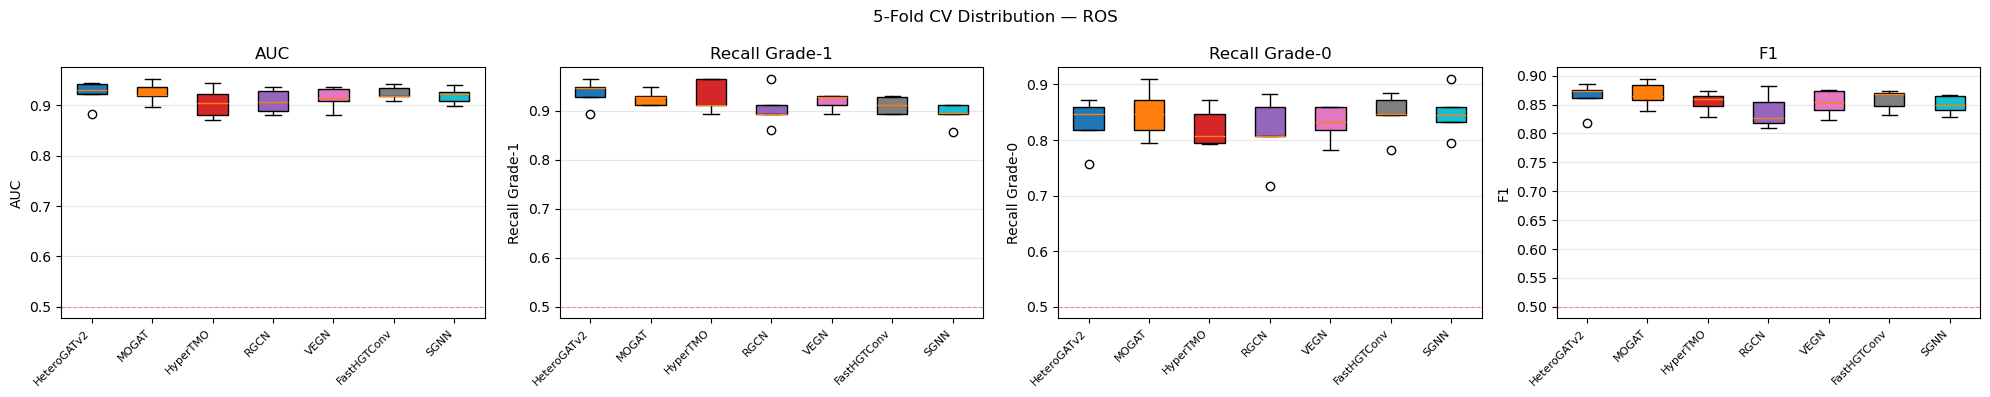

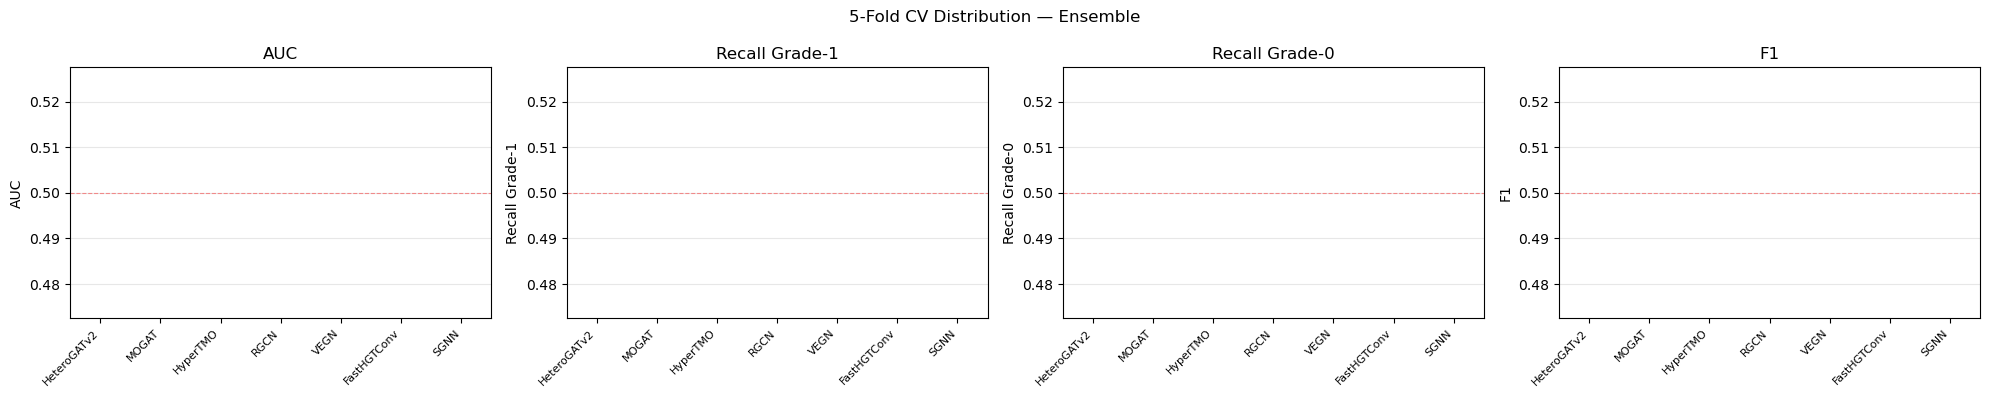

In [25]:
metrics_cv = ['auc', 'recall', 'recall_0', 'f1']
labels_cv  = ['AUC', 'Recall Grade-1', 'Recall Grade-0', 'F1']
model_names = [n for n, _, _ in MODEL_REGISTRY]

for pipe in PIPELINES:
    sub = cv_all[cv_all.Pipeline == pipe]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, met, lab in zip(axes, metrics_cv, labels_cv):
        data = [sub[sub.Model == m][met].values for m in model_names]
        bp = ax.boxplot(data, patch_artist=True, notch=False)
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))
        for patch, col in zip(bp['boxes'], colors):
            patch.set_facecolor(col)
        ax.set_xticks(range(1, len(model_names)+1))
        ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(lab); ax.set_title(lab); ax.grid(axis='y', alpha=0.3)
        ax.axhline(0.5, color='red', ls='--', alpha=0.4, lw=0.8)
    plt.suptitle(f'5-Fold CV Distribution — {pipe}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V15_cv_boxplot_{pipe.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 21. ROC Curve Grid

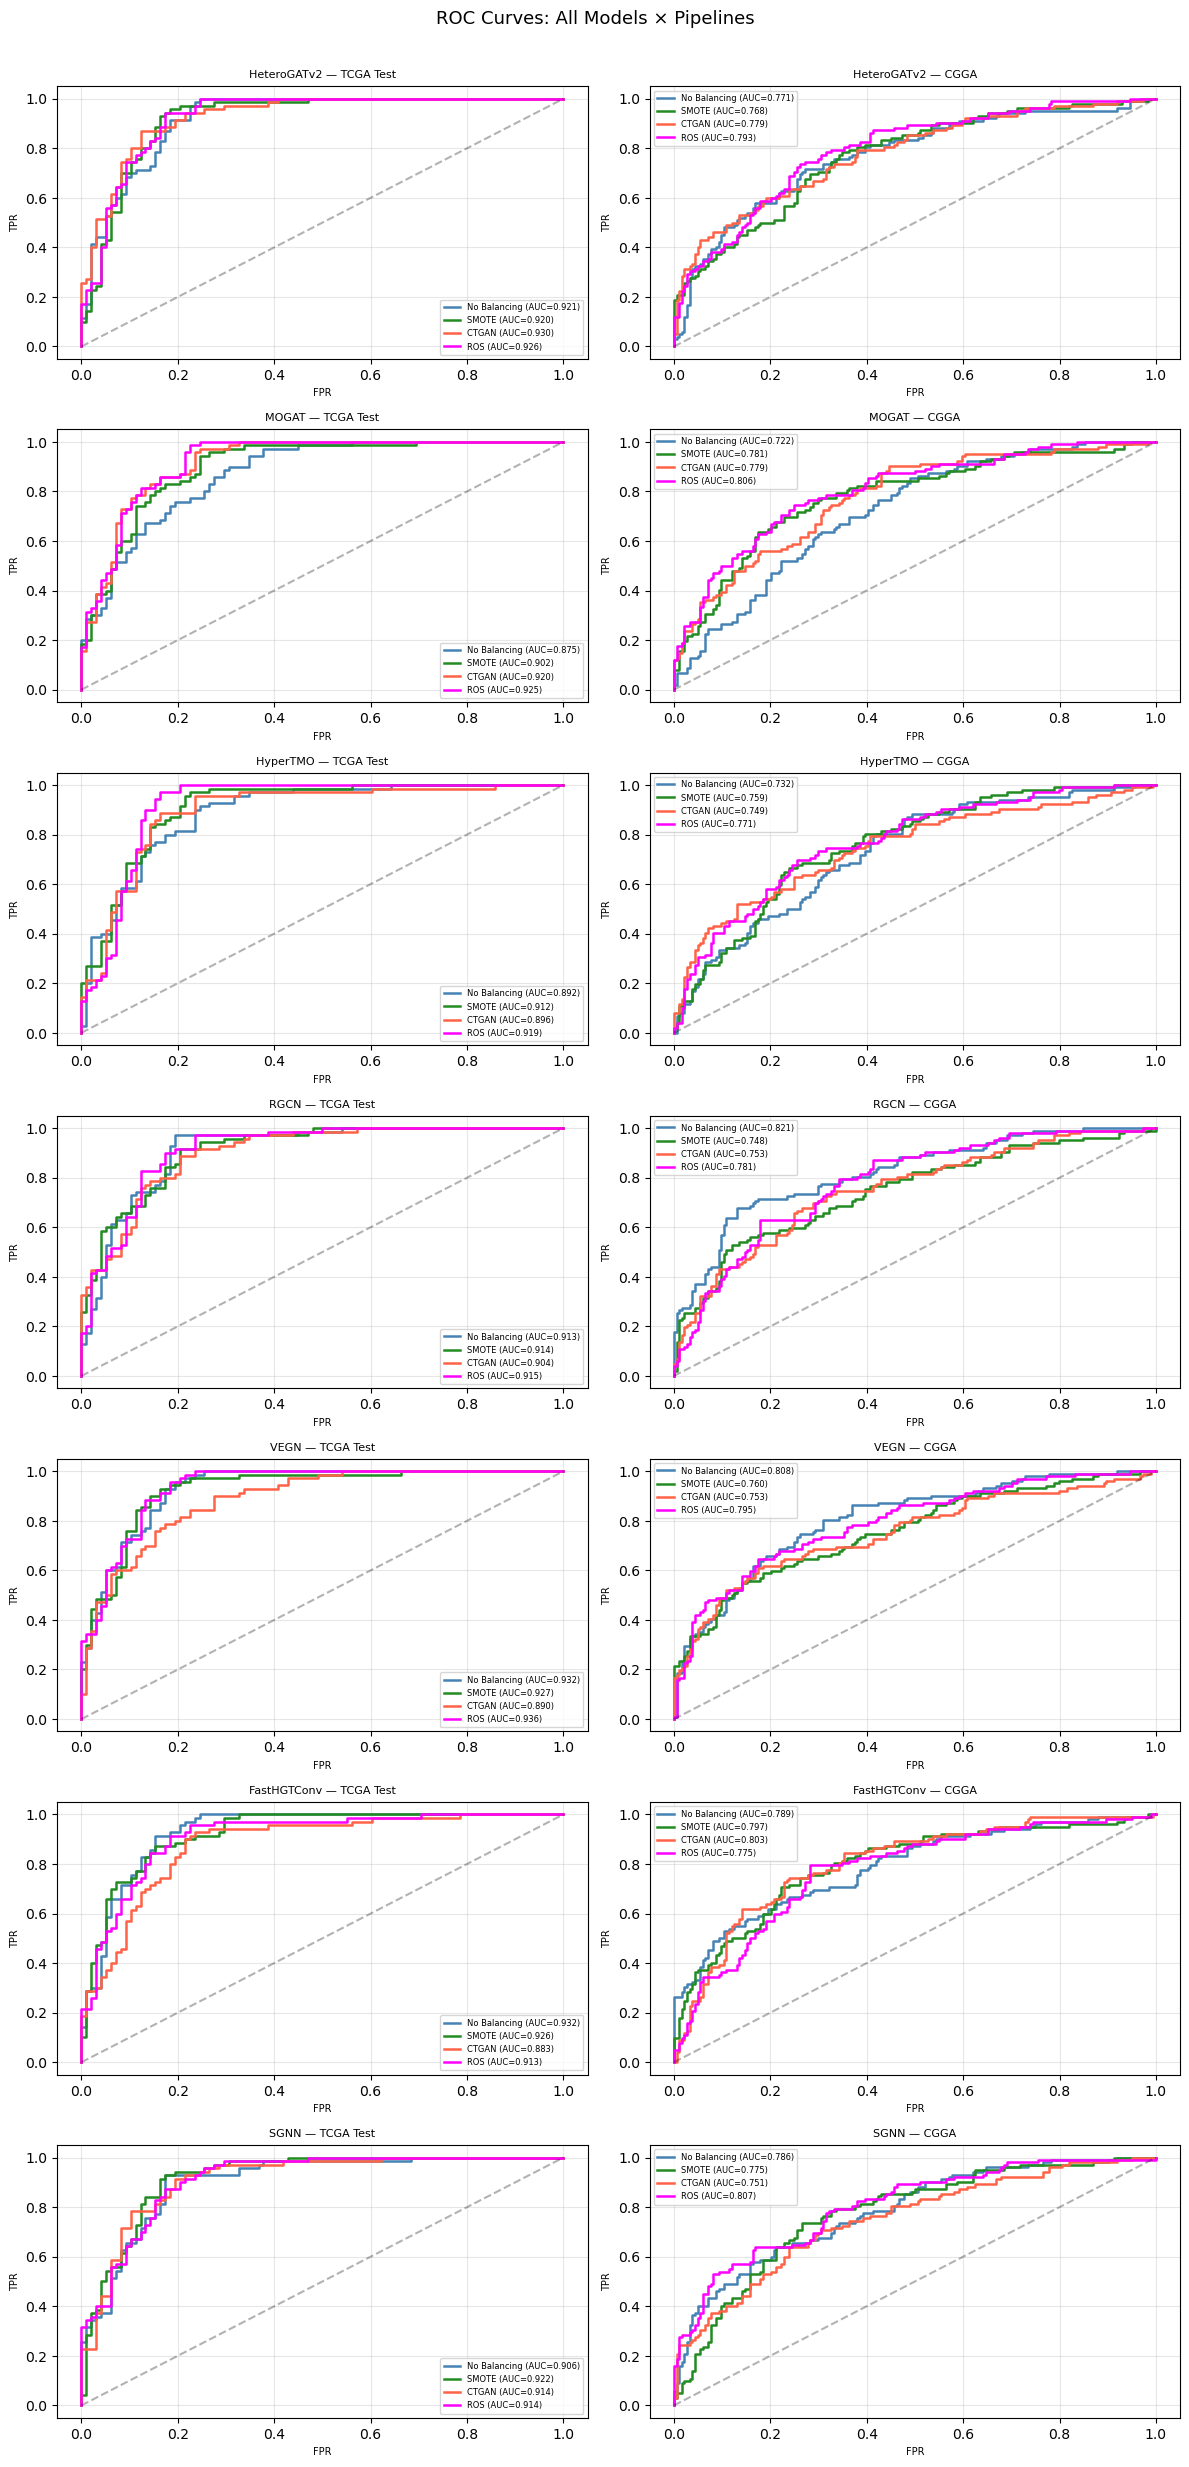

In [26]:
results_full = pd.DataFrame(all_results)
pipe_colors  = {'No Balancing':'steelblue', 'SMOTE':'forestgreen', 'CTGAN':'tomato'}
pipe_colors['ROS'] = 'magenta'
#pipe_colors['ROS+SF'] = 'cyan'

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            r = sub.iloc[0]
            fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} (AUC={r['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8)
        ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves: All Models × Pipelines', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('V15_roc_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Confusion Matrices

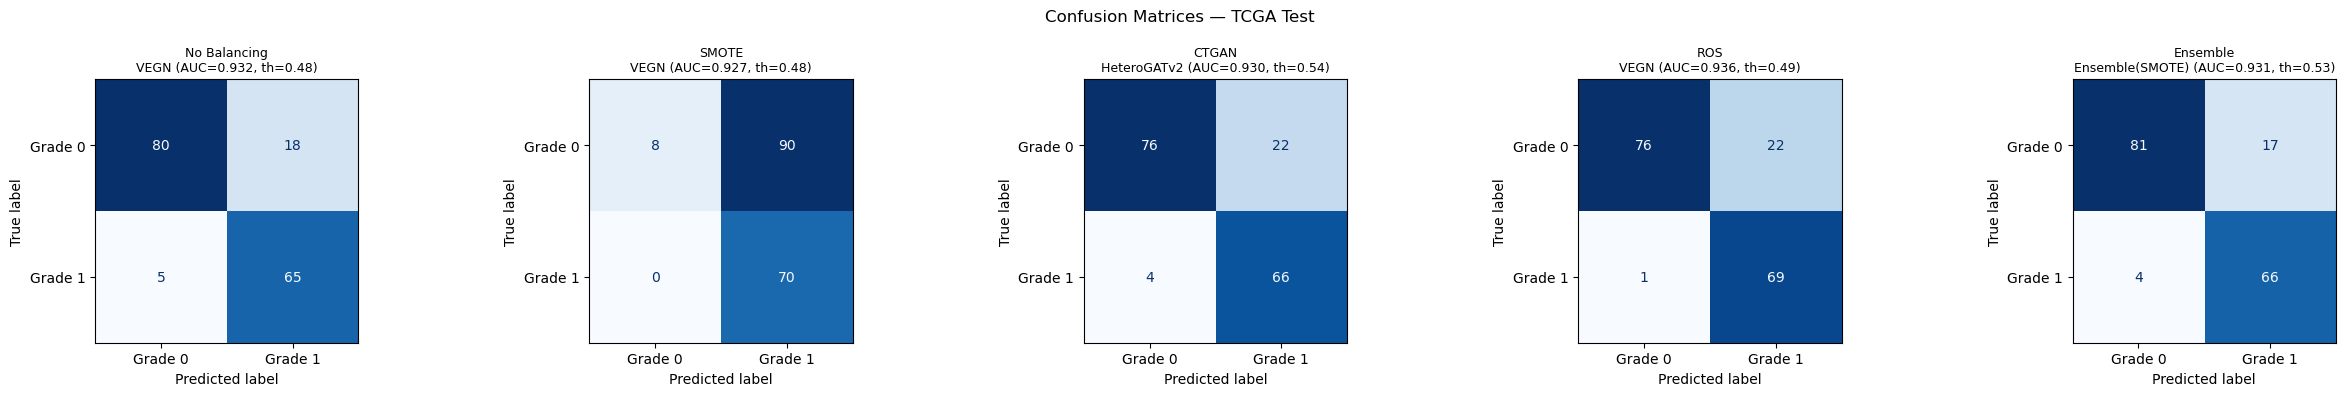

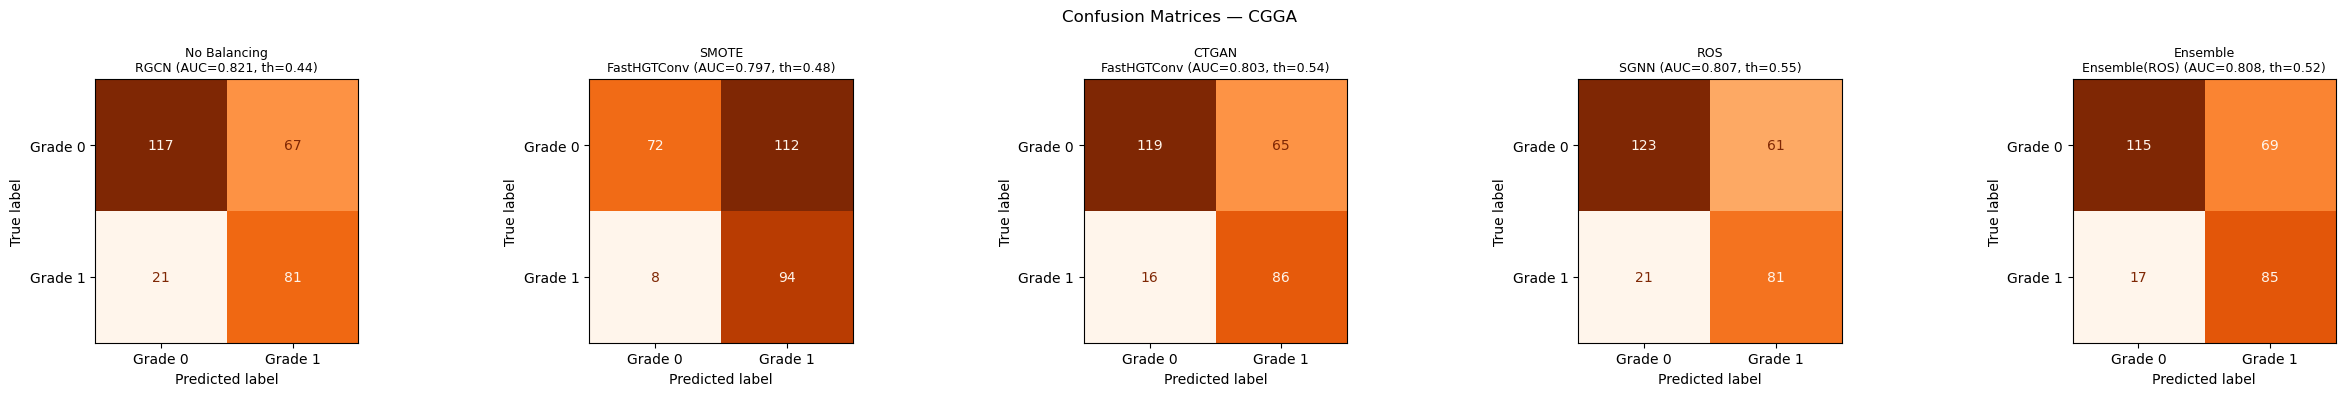

In [27]:
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, len(PIPELINES), figsize=(5*len(PIPELINES), 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        if sub.empty: continue
        best = sub.loc[sub['auc'].idxmax()]
        th   = best['threshold']
        preds = (best['probs'] >= th).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f}, th={th:.2f})",
                           fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V15_cm_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 23. Permutation Feature Importance — Genes + Clinical Features

For every feature (20 gene mutations + 3 clinical: **Age_at_diagnosis, Gender, Race**),
the column is shuffled `n_repeats=10` times and the mean AUC drop is recorded.

- **Gene features** are permuted as binary mutation columns
- **Clinical features** are permuted as continuous/categorical columns in the same way
- The graph is rebuilt from scratch after each permutation so the message-passing
  structure reflects the shuffled values
- Larger AUC drop → feature is more important for classification

In [28]:
# All features subject to permutation importance
CLINICAL_FEATURES = ['Age_at_diagnosis', 'Gender', 'Race']
ALL_FEATURES      = gene_columns + CLINICAL_FEATURES   # 20 genes + 3 clinical = 23 total


def perm_importance_all(model, ref_df, threshold=0.5, n_repeats=10, seed=0):
    """Permutation importance for ALL features (genes + clinical).
    Returns ({feature: mean_auc_drop}, base_auc).
    """
    # V13: use SF graph so permutation test matches training graph topology
    base_g = to_dev(construct_scalefree_bipartite_heterograph(ref_df))
    model.eval()
    with torch.no_grad():
        bp = F.softmax(model(base_g), 1)[:, 1].cpu().numpy()
    try:
        base_auc = roc_auc_score(ref_df['Grade'].values, bp)
    except ValueError:
        return {f: 0.0 for f in ALL_FEATURES}, 0.0

    rng = np.random.default_rng(seed)
    out = {}

    for feat in ALL_FEATURES:
        drops = []
        for _ in range(n_repeats):
            df2         = ref_df.copy()
            df2[feat]   = rng.permutation(df2[feat].values)  # shuffle this feature
            g2          = to_dev(construct_scalefree_bipartite_heterograph(df2))
            with torch.no_grad():
                pp = F.softmax(model(g2), 1)[:, 1].cpu().numpy()
            try:
                drops.append(base_auc - roc_auc_score(ref_df['Grade'].values, pp))
            except ValueError:
                drops.append(0.0)
        out[feat] = float(np.mean(drops))

    clear_pp_cache()
    return out, base_auc


print("Computing permutation importance for genes + clinical features...")
print(f"Features: {len(ALL_FEATURES)} total ({len(gene_columns)} genes + {len(CLINICAL_FEATURES)} clinical)")
print(f"Models: {len(MODEL_REGISTRY)} × Pipelines: {len(PIPELINES)} = {len(MODEL_REGISTRY)*len(PIPELINES)} combinations")
print(f"Repeats per feature: 10  →  Total graph builds: {len(ALL_FEATURES)*10*len(MODEL_REGISTRY)*len(PIPELINES):,}")

imp_records = []
for mname, MCls, _ in MODEL_REGISTRY:
    for pipe in PIPELINES:
        model = all_models.get((mname, pipe))
        if model is None: continue
        th        = all_thresholds.get((mname, pipe), 0.5)
        imp, base = perm_importance_all(model, test_df, threshold=th)
        for feat, drop in imp.items():
            imp_records.append({
                'Model':        mname,
                'Pipeline':     pipe,
                'Feature':      feat,
                'Feature_Type': 'Clinical' if feat in CLINICAL_FEATURES else 'Gene',
                'AUC_Drop':     drop,
                'Base_AUC':     base,
            })
        print(f"  {mname}/{pipe}  base={base:.4f}")

imp_df = pd.DataFrame(imp_records)
imp_df.to_csv('V15_feature_importance.csv', index=False)
print(f"\nDone. Saved V15_feature_importance.csv ({len(imp_df)} rows)")

Computing permutation importance for genes + clinical features...
Features: 23 total (20 genes + 3 clinical)
Models: 7 × Pipelines: 5 = 35 combinations
Repeats per feature: 10  →  Total graph builds: 8,050
  HeteroGATv2/No Balancing  base=0.9210
  HeteroGATv2/SMOTE  base=0.9201
  HeteroGATv2/CTGAN  base=0.9297
  HeteroGATv2/ROS  base=0.9262
  MOGAT/No Balancing  base=0.8748
  MOGAT/SMOTE  base=0.9022
  MOGAT/CTGAN  base=0.9204
  MOGAT/ROS  base=0.9249
  HyperTMO/No Balancing  base=0.8923
  HyperTMO/SMOTE  base=0.9115
  HyperTMO/CTGAN  base=0.8962
  HyperTMO/ROS  base=0.9191
  RGCN/No Balancing  base=0.9133
  RGCN/SMOTE  base=0.9138
  RGCN/CTGAN  base=0.9041
  RGCN/ROS  base=0.9153
  VEGN/No Balancing  base=0.9322
  VEGN/SMOTE  base=0.9271
  VEGN/CTGAN  base=0.8901
  VEGN/ROS  base=0.9364
  FastHGTConv/No Balancing  base=0.9318
  FastHGTConv/SMOTE  base=0.9261
  FastHGTConv/CTGAN  base=0.8825
  FastHGTConv/ROS  base=0.9130
  SGNN/No Balancing  base=0.9061
  SGNN/SMOTE  base=0.9217
  SGN

## 24. Feature Importance Plots — Genes + Clinical

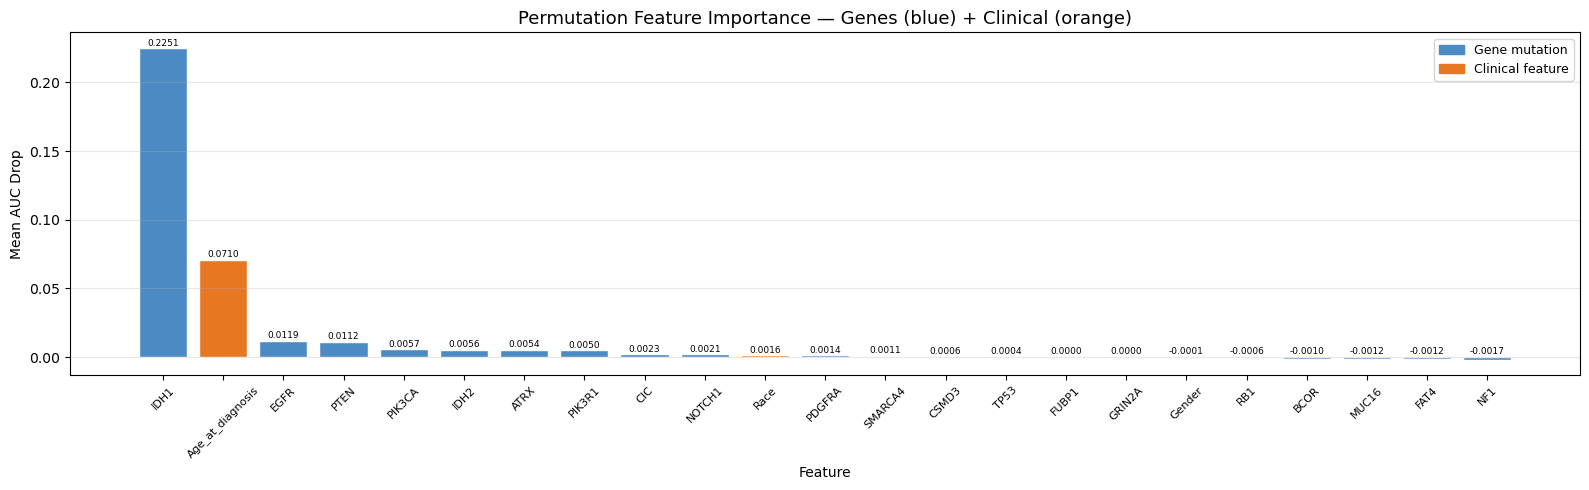

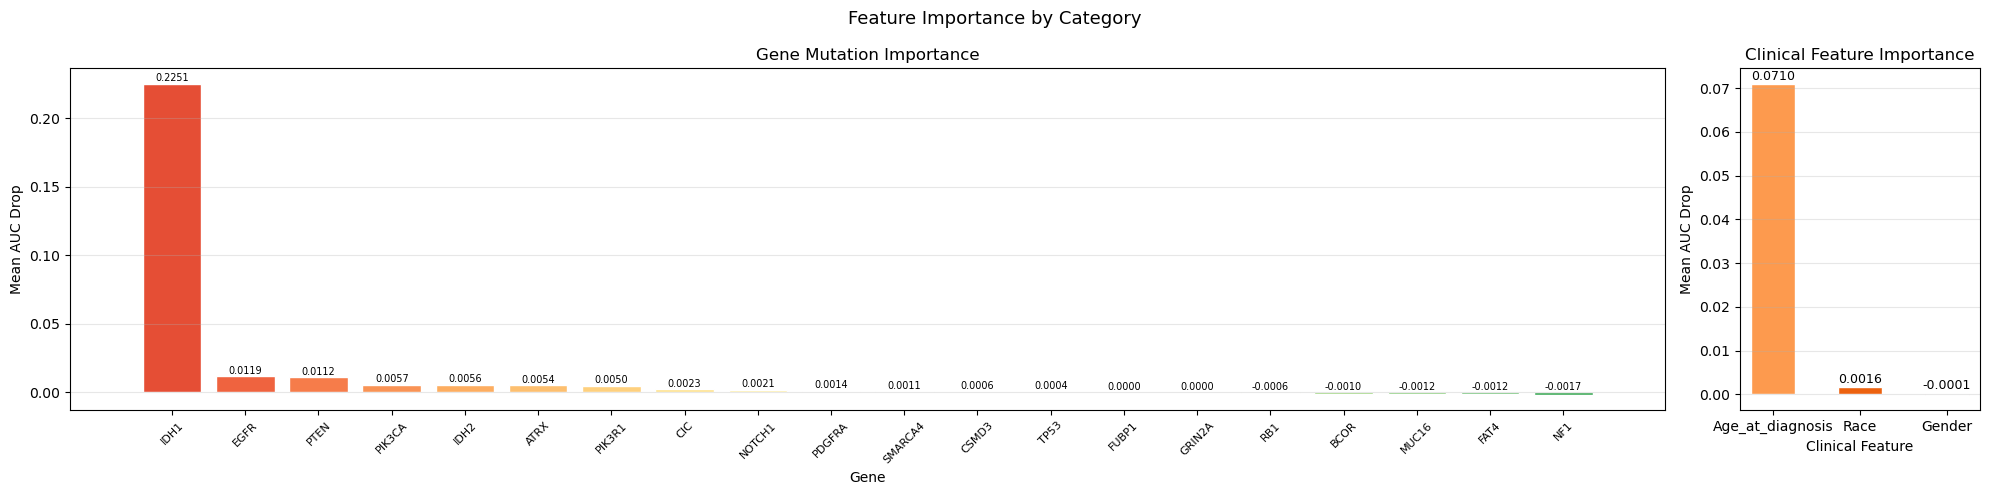

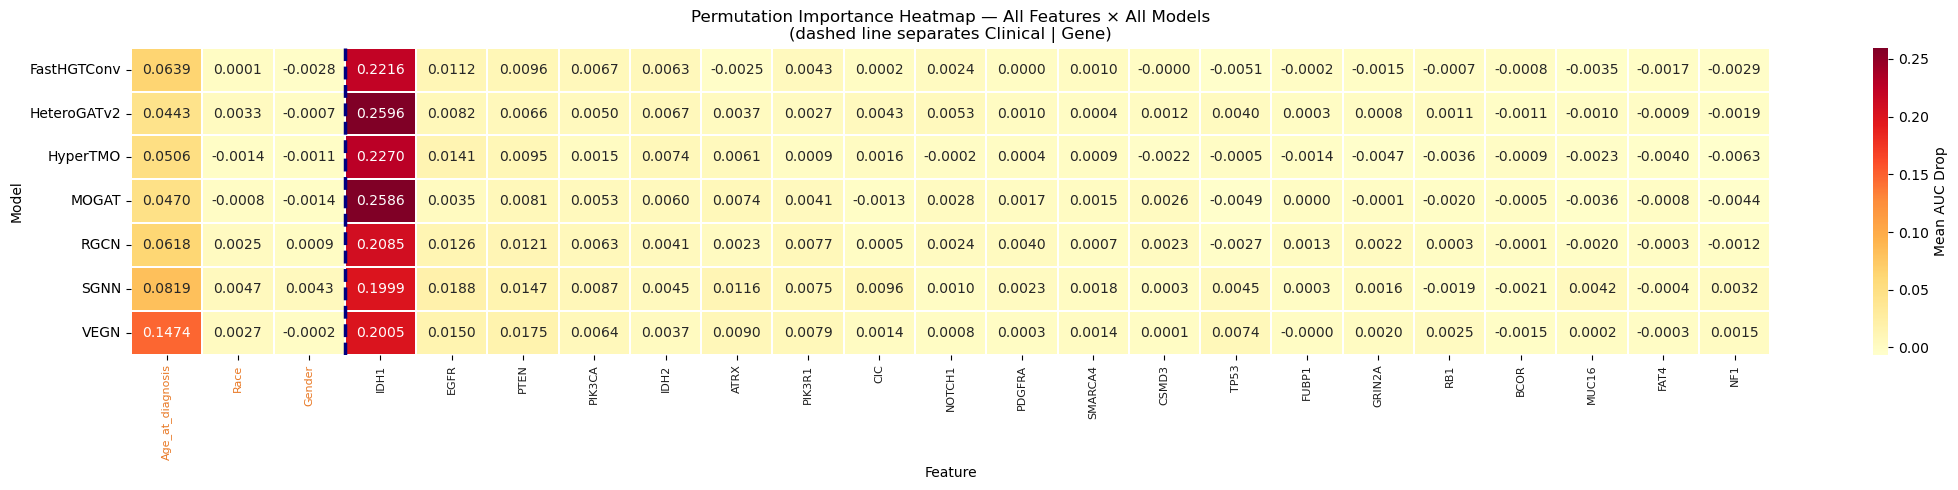

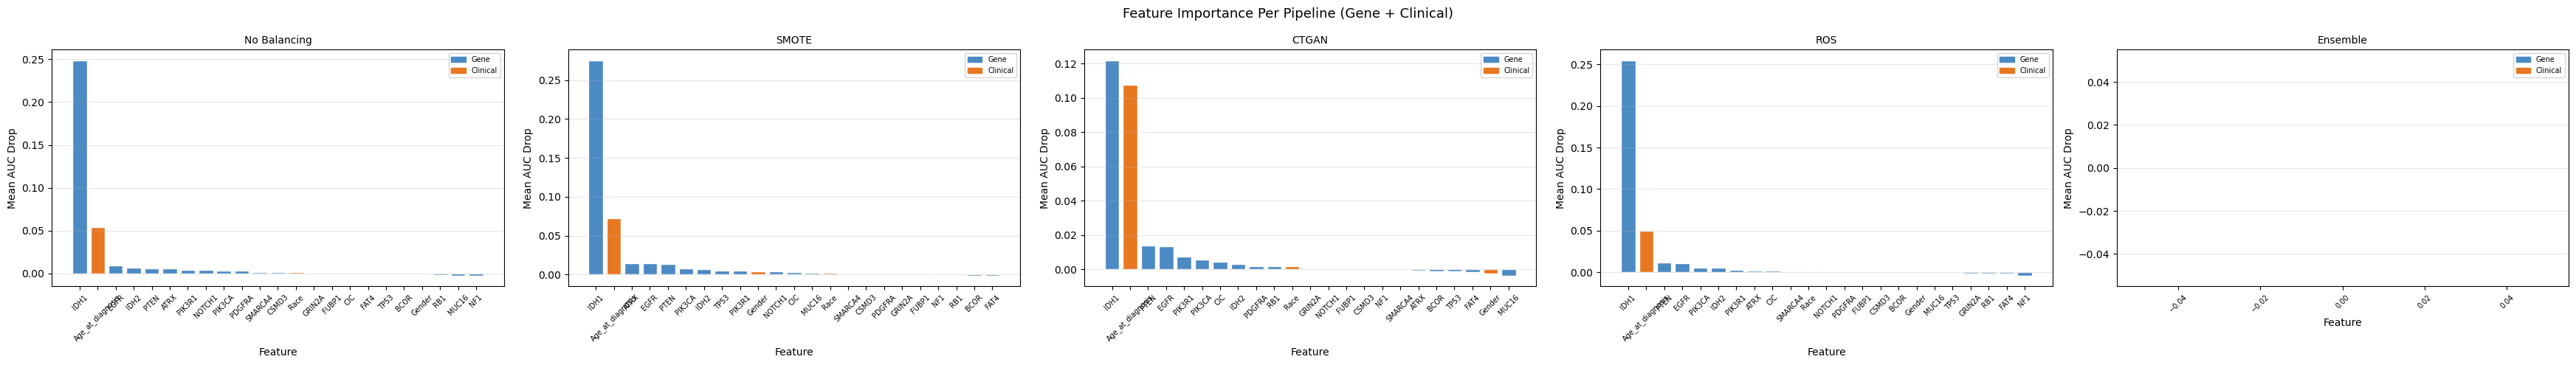


OVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)
   1. [GENE]     IDH1                  0.2251
   2. [CLINICAL]  Age_at_diagnosis      0.0710
   3. [GENE]     EGFR                  0.0119
   4. [GENE]     PTEN                  0.0112
   5. [GENE]     PIK3CA                0.0057
   6. [GENE]     IDH2                  0.0056
   7. [GENE]     ATRX                  0.0054
   8. [GENE]     PIK3R1                0.0050
   9. [GENE]     CIC                   0.0023
  10. [GENE]     NOTCH1                0.0021
  11. [CLINICAL]  Race                  0.0016
  12. [GENE]     PDGFRA                0.0014
  13. [GENE]     SMARCA4               0.0011
  14. [GENE]     CSMD3                 0.0006
  15. [GENE]     TP53                  0.0004
  16. [GENE]     FUBP1                 0.0000
  17. [GENE]     GRIN2A                0.0000
  18. [CLINICAL]  Gender                -0.0001
  19. [GENE]     RB1                   -0.0006
  20. [GENE]     BCOR                  

In [29]:
# ── Aggregate: mean AUC drop per feature across all models & pipelines ──
mean_imp = (imp_df.groupby(['Feature','Feature_Type'])['AUC_Drop']
            .mean()
            .reset_index()
            .sort_values('AUC_Drop', ascending=False)
            .reset_index(drop=True))

# Colour: orange for clinical, steelblue for gene
bar_colors = ['#E87722' if t == 'Clinical' else '#4C8AC4'
              for t in mean_imp['Feature_Type']]

# ─────────────────────────────────────────────────────────────────
# PLOT A: Combined bar chart — all 23 features, colour-coded by type
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(mean_imp['Feature'], mean_imp['AUC_Drop'], color=bar_colors, edgecolor='white')
ax.set_xlabel('Feature'); ax.set_ylabel('Mean AUC Drop')
ax.set_title('Permutation Feature Importance — Genes (blue) + Clinical (orange)', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, mean_imp['AUC_Drop']):
    ax.text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
            f'{v:.4f}', ha='center', va='bottom', fontsize=6.5)

# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C8AC4', label='Gene mutation'),
                    Patch(color='#E87722', label='Clinical feature')],
           fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('V15_feat_importance_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT B: Side-by-side — Gene panel | Clinical panel
# ─────────────────────────────────────────────────────────────────
gene_imp = mean_imp[mean_imp.Feature_Type == 'Gene'].copy()
clin_imp = mean_imp[mean_imp.Feature_Type == 'Clinical'].copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 5),
                          gridspec_kw={'width_ratios': [len(gene_imp), len(clin_imp)]})

# Gene panel
gcols = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(gene_imp)))
b1 = axes[0].bar(gene_imp['Feature'], gene_imp['AUC_Drop'], color=gcols, edgecolor='white')
axes[0].set_title('Gene Mutation Importance', fontsize=12)
axes[0].set_xlabel('Gene'); axes[0].set_ylabel('Mean AUC Drop')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].grid(axis='y', alpha=0.3)
for b, v in zip(b1, gene_imp['AUC_Drop']):
    axes[0].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=7)

# Clinical panel
ccols = plt.cm.Oranges(np.linspace(0.45, 0.85, len(clin_imp)))
b2 = axes[1].bar(clin_imp['Feature'], clin_imp['AUC_Drop'], color=ccols, edgecolor='white',
                  width=0.5)
axes[1].set_title('Clinical Feature Importance', fontsize=12)
axes[1].set_xlabel('Clinical Feature'); axes[1].set_ylabel('Mean AUC Drop')
axes[1].tick_params(axis='x', rotation=0, labelsize=10)
axes[1].grid(axis='y', alpha=0.3)
for b, v in zip(b2, clin_imp['AUC_Drop']):
    axes[1].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Feature Importance by Category', fontsize=13)
plt.tight_layout()
plt.savefig('V15_feat_importance_sidebyside.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT C: Heatmap — all 23 features × 7 models (averaged over pipelines)
# ─────────────────────────────────────────────────────────────────
# Column order: clinical first, then genes sorted by mean importance
col_order = (list(clin_imp['Feature']) +
             list(gene_imp.sort_values('AUC_Drop', ascending=False)['Feature']))

heat = (imp_df.groupby(['Model','Feature'])['AUC_Drop']
        .mean()
        .unstack('Feature')
        .reindex(columns=col_order))

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.35,
            ax=ax, cbar_kws={'label': 'Mean AUC Drop'})

# Vertical separator between clinical and gene columns
ax.axvline(x=len(CLINICAL_FEATURES), color='navy', lw=2.5, ls='--')

ax.set_title('Permutation Importance Heatmap — All Features × All Models\n'
             '(dashed line separates Clinical | Gene)', fontsize=12)

ax.set_xlabel('Feature'); ax.set_ylabel('Model')

# Colour x-tick labels by type
for tick, feat in zip(ax.get_xticklabels(), col_order):
    tick.set_color('#E87722' if feat in CLINICAL_FEATURES else '#1a1a1a')
    tick.set_fontsize(8)

plt.tight_layout()
plt.savefig('V15_feat_importance_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT D: Per-pipeline importance — clinical vs gene
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(PIPELINES), figsize=(7 * len(PIPELINES), 5))
for pi, pipe in enumerate(PIPELINES):
    sub = (imp_df[imp_df.Pipeline == pipe]
           .groupby(['Feature','Feature_Type'])['AUC_Drop'].mean()
           .reset_index()
           .sort_values('AUC_Drop', ascending=False))
    colors_p = ['#E87722' if t == 'Clinical' else '#4C8AC4'
                for t in sub['Feature_Type']]
    axes[pi].bar(sub['Feature'], sub['AUC_Drop'], color=colors_p, edgecolor='white')
    axes[pi].set_title(f'{pipe}', fontsize=10)
    axes[pi].set_xlabel('Feature'); axes[pi].set_ylabel('Mean AUC Drop')
    axes[pi].tick_params(axis='x', rotation=45, labelsize=7)
    axes[pi].grid(axis='y', alpha=0.3)
    axes[pi].legend(handles=[Patch(color='#4C8AC4', label='Gene'),
                               Patch(color='#E87722', label='Clinical')],
                     fontsize=7)
plt.suptitle('Feature Importance Per Pipeline (Gene + Clinical)', fontsize=13)
plt.tight_layout()
plt.savefig('V15_feat_importance_per_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────
print("\nOVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)")
print("="*65)
for i, row in mean_imp.iterrows():
    tag = '[CLINICAL]' if row['Feature_Type'] == 'Clinical' else '[GENE]   '
    print(f"  {i+1:2d}. {tag}  {row['Feature']:20s}  {row['AUC_Drop']:.4f}")

print(f"\nClinical features summary:")
for _, row in clin_imp.iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

print(f"\nTop-5 gene features:")
for _, row in gene_imp.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

## 25. GAT & MOGAT Attention Weights

**HeteroGATv2**: gene→patient GATv2 attention.  
**MOGAT**: same gene→patient GATv2 genomic attention **plus** the fusion gate values showing how much each patient relies on the genomic vs clinical pathway.


Attention: HeteroGATv2 / No Balancing


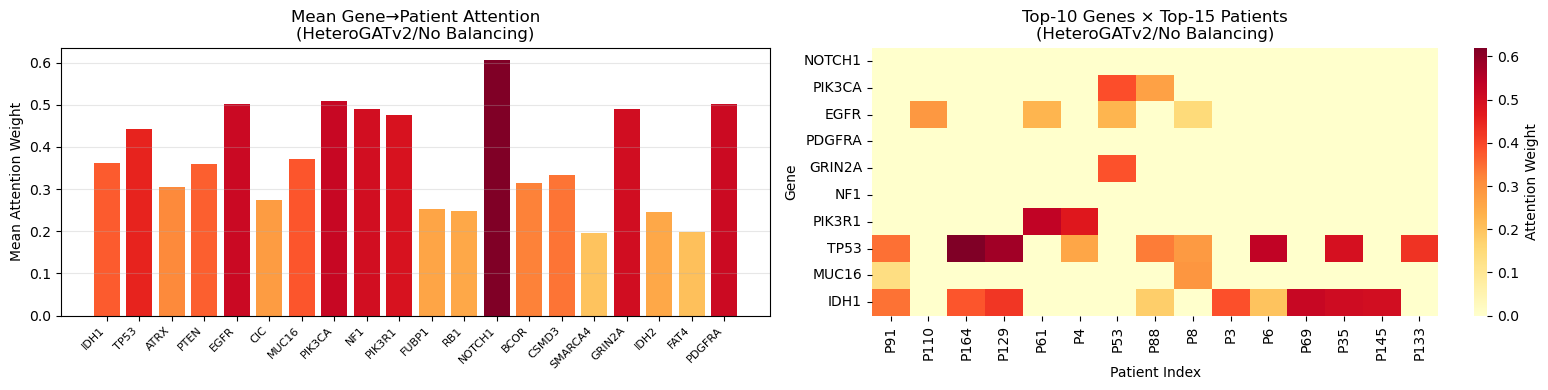


Attention: MOGAT / No Balancing


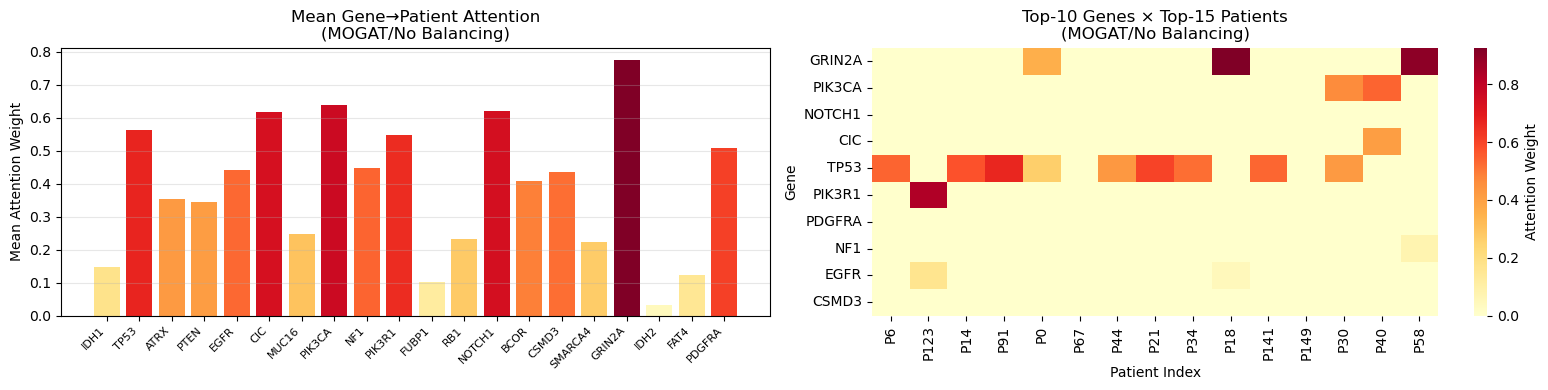

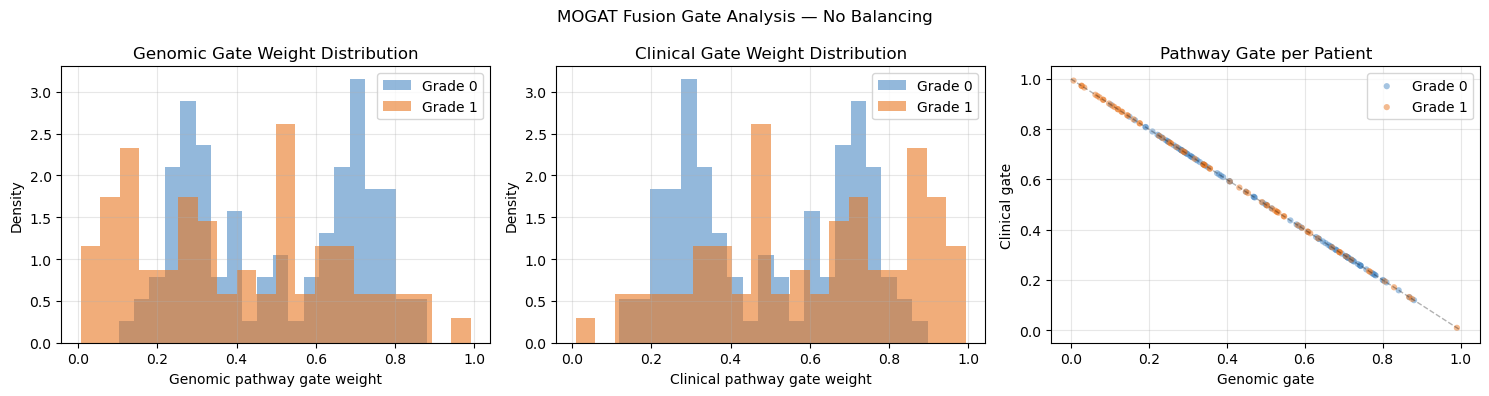


Attention: HeteroGATv2 / SMOTE


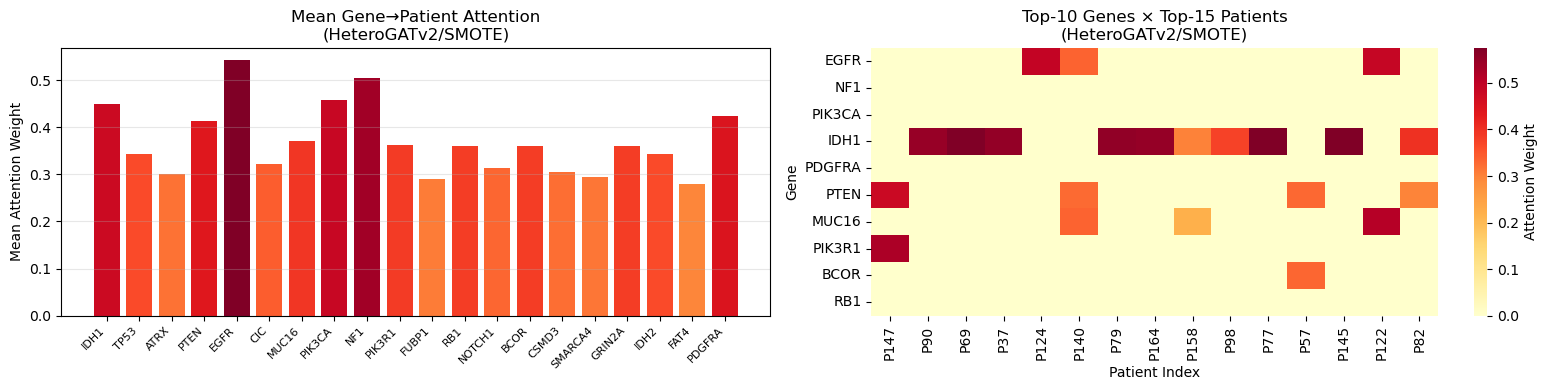


Attention: MOGAT / SMOTE


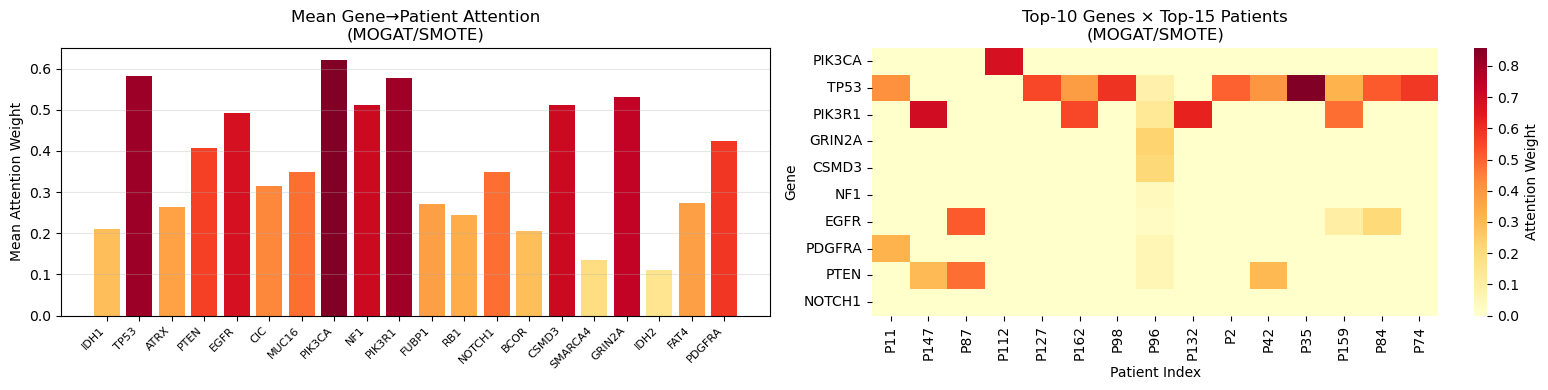

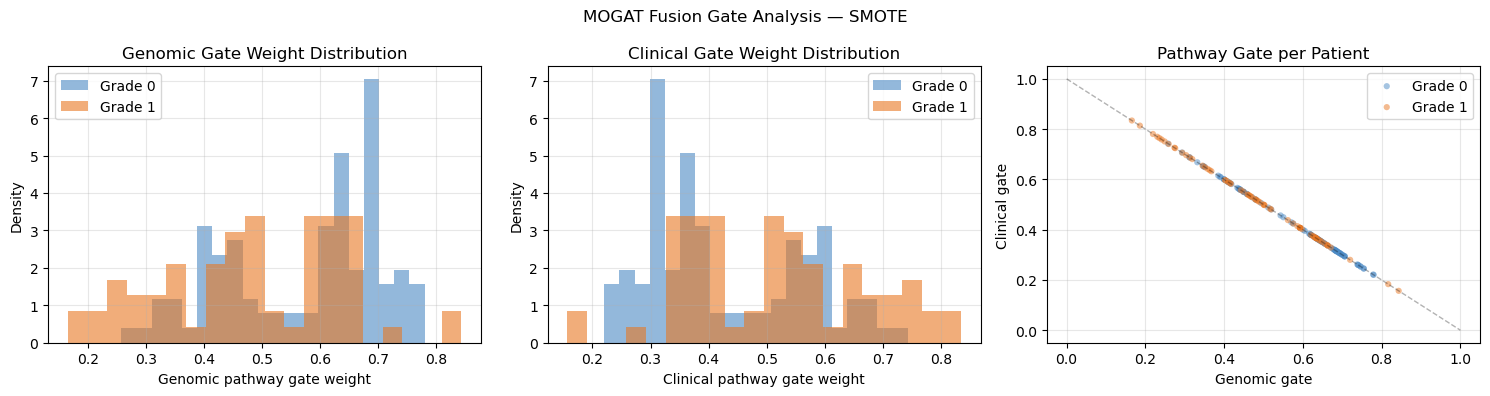


Attention: HeteroGATv2 / CTGAN


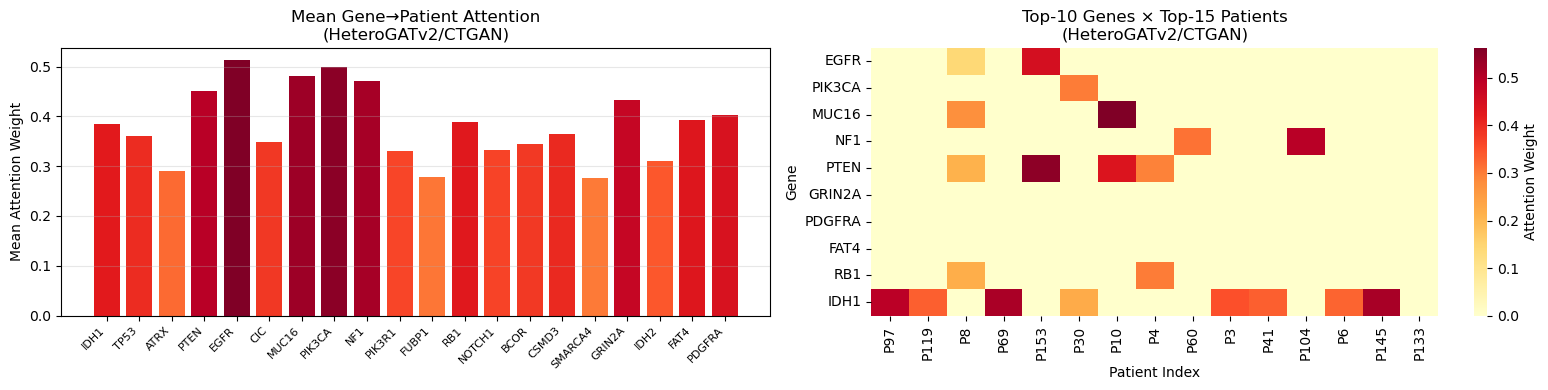


Attention: MOGAT / CTGAN


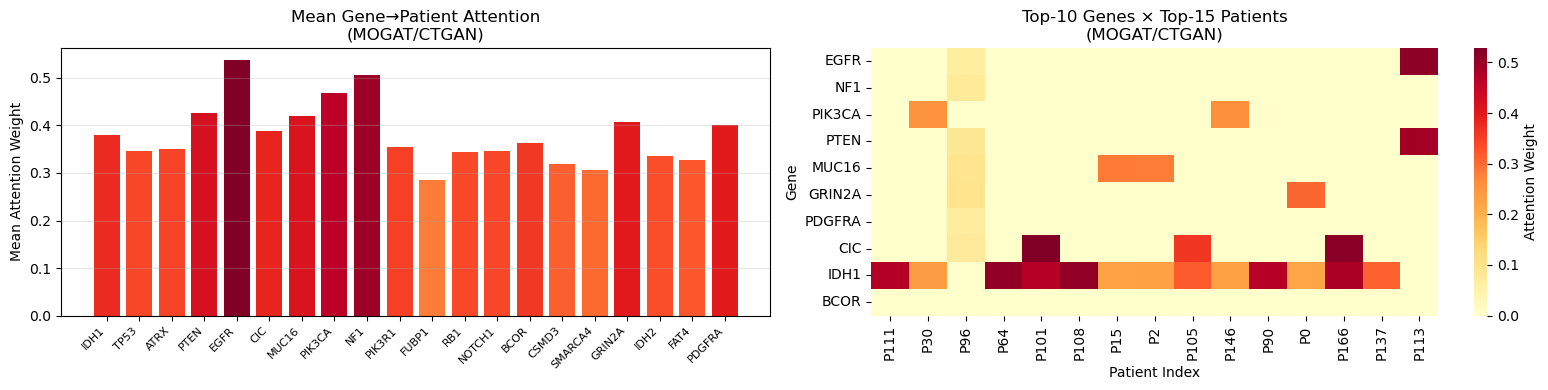

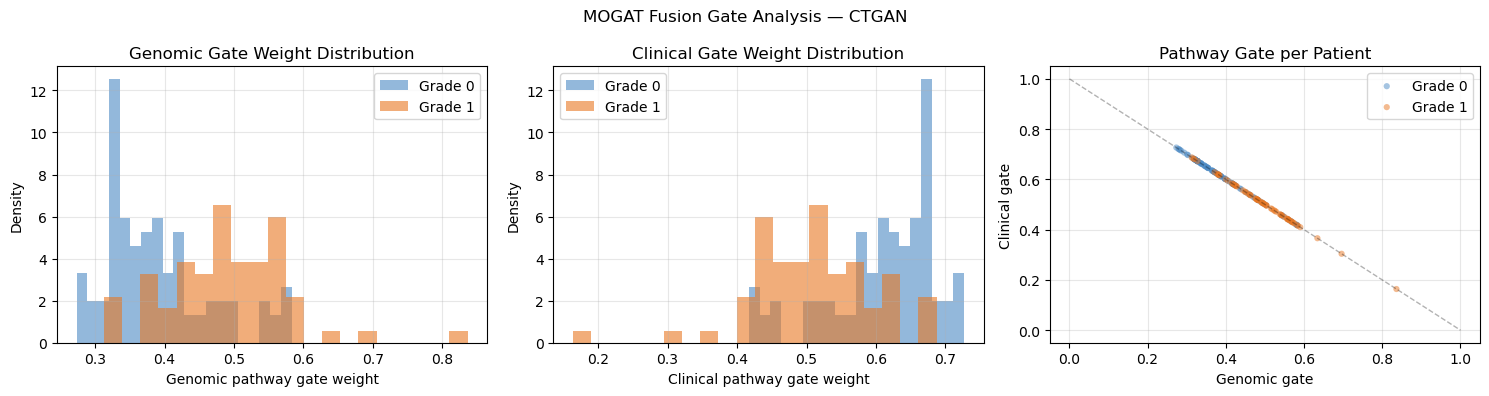


Attention: HeteroGATv2 / ROS


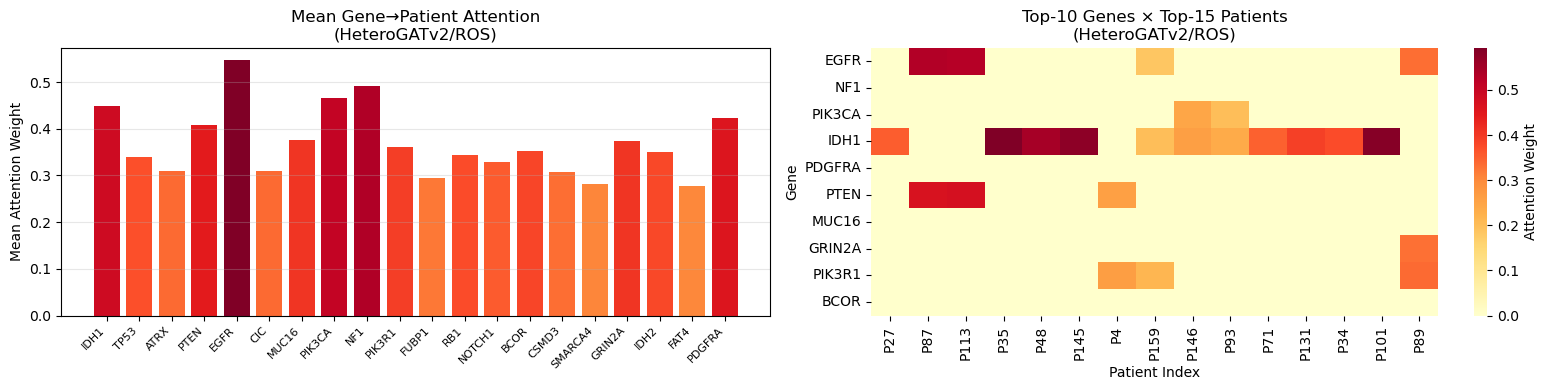


Attention: MOGAT / ROS


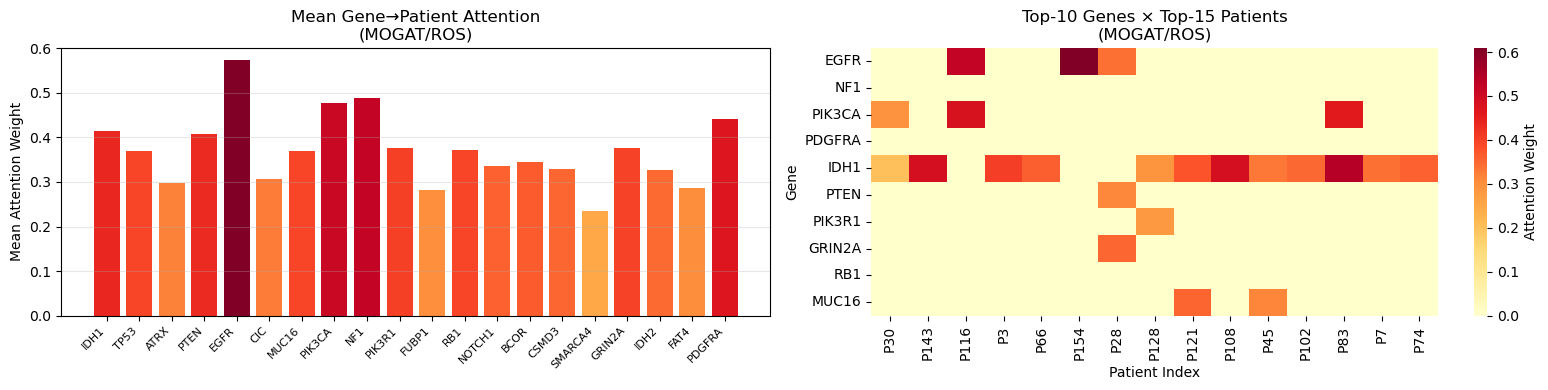

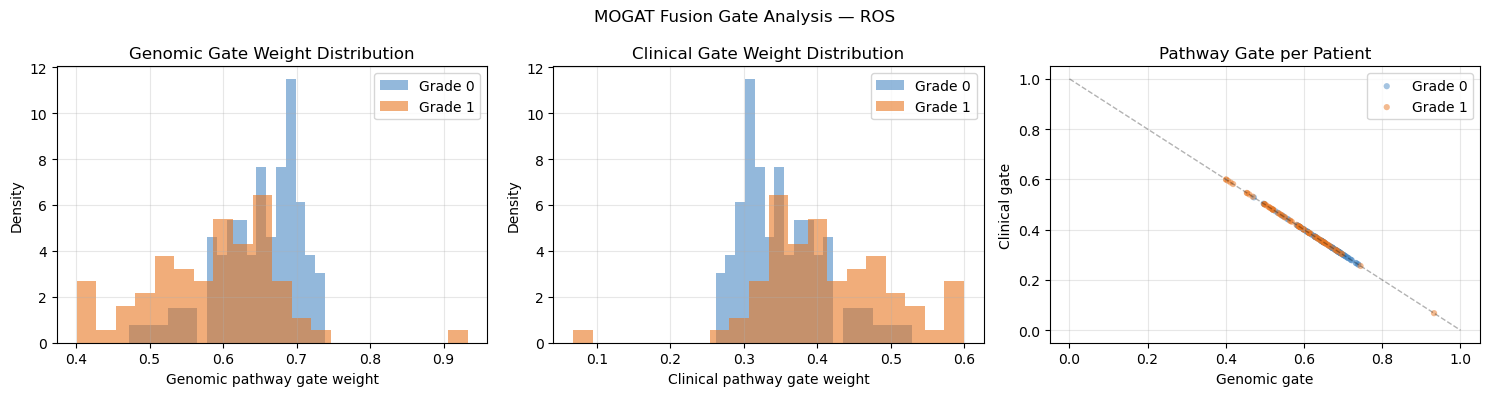

In [30]:
def plot_gene_attention(model, graph, ref_df, title):
    """Visualise gene->patient attention for any model that exposes get_attn_weights().
    For MOGAT the function also prints the fusion gate split (printed inside get_attn_weights).
    """
    model.eval()
    if not hasattr(model, 'get_attn_weights'):
        print(f"  {type(model).__name__} has no get_attn_weights — skipping.")
        return
    try:
        eidx, weights = model.get_attn_weights(graph)
    except Exception as e:
        print(f"  Attention extraction failed: {e}"); return

    gene_ids = eidx[0].cpu().numpy()
    pat_ids  = eidx[1].cpu().numpy()
    w        = weights.cpu().numpy()

    # Mean attention weight per gene (averaged over all edges touching that gene)
    gene_attn = np.zeros(NUM_GENES); gene_cnt = np.zeros(NUM_GENES)
    for g, wt in zip(gene_ids, w):
        if 0 <= g < NUM_GENES:
            gene_attn[g] += wt; gene_cnt[g] += 1
    gene_cnt  = np.maximum(gene_cnt, 1)
    gene_attn /= gene_cnt

    # Top-10 genes and top-15 patients by total received attention
    n_pat = ref_df.shape[0]
    top_g  = np.argsort(gene_attn)[::-1][:10]
    pat_wsum = np.zeros(n_pat)
    for g, p, wt in zip(gene_ids, pat_ids, w):
        if 0 <= p < n_pat: pat_wsum[p] += wt
    top_p = np.argsort(pat_wsum)[::-1][:15]

    mat = np.zeros((len(top_g), len(top_p)))
    for g_loc, g in enumerate(top_g):
        for p_loc, p in enumerate(top_p):
            mask = (gene_ids == g) & (pat_ids == p)
            if mask.any(): mat[g_loc, p_loc] = w[mask].mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Bar chart: mean attention per gene
    norm_a = gene_attn / (gene_attn.max() + 1e-9)
    axes[0].bar(gene_columns, gene_attn, color=plt.cm.YlOrRd(norm_a))
    axes[0].set_xticklabels(gene_columns, rotation=45, ha='right', fontsize=8)
    axes[0].set_title(f'Mean Gene→Patient Attention\n({title})')
    axes[0].set_ylabel('Mean Attention Weight'); axes[0].grid(axis='y', alpha=0.3)

    # Heatmap: top genes × top patients
    sns.heatmap(mat, ax=axes[1], cmap='YlOrRd',
                xticklabels=[f'P{p}' for p in top_p],
                yticklabels=[gene_columns[g] for g in top_g],
                cbar_kws={'label': 'Attention Weight'})
    axes[1].set_title(f'Top-10 Genes × Top-15 Patients\n({title})')
    axes[1].set_xlabel('Patient Index'); axes[1].set_ylabel('Gene')

    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V15_attn_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── MOGAT: also show per-patient fusion gate distribution ─────────
def plot_mogat_fusion_gate(model, graph, ref_df, title):
    """Show the distribution of genomic vs clinical pathway weights
    (the learned soft gate) across all patients."""
    model.eval()
    if not isinstance(model, MOGAT):
        return
    with torch.no_grad():
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(model.pg(graph['Patient'].x))
        hgg = F.relu(model.gg(graph['Gene'].x))
        hpg_out = F.leaky_relu(model.gat((hgg, hpg), e), 0.2)
        hpc     = model.mlp(F.relu(model.pc(graph['Patient'].x)))
        gate_w  = torch.softmax(model.gate(torch.cat([hpg_out, hpc], -1)), dim=-1)
        gw      = gate_w.cpu().numpy()   # [n_patients, 2]  col0=genomic, col1=clinical

    labels  = ref_df['Grade'].values
    grades  = ['Grade 0', 'Grade 1']
    colors  = ['#4C8AC4', '#E87722']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram of genomic gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[0].hist(gw[mask, 0], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[0].set_xlabel('Genomic pathway gate weight'); axes[0].set_ylabel('Density')
    axes[0].set_title('Genomic Gate Weight Distribution'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Histogram of clinical gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[1].hist(gw[mask, 1], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[1].set_xlabel('Clinical pathway gate weight'); axes[1].set_ylabel('Density')
    axes[1].set_title('Clinical Gate Weight Distribution'); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Scatter: genomic vs clinical gate per patient, coloured by grade
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[2].scatter(gw[mask, 0], gw[mask, 1], c=color, label=lbl,
                         alpha=0.5, s=20, edgecolors='none')
    axes[2].plot([0,1],[1,0],'k--', alpha=0.3, lw=1)   # gate sums to 1
    axes[2].set_xlabel('Genomic gate'); axes[2].set_ylabel('Clinical gate')
    axes[2].set_title('Pathway Gate per Patient'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(f'MOGAT Fusion Gate Analysis — {title}', fontsize=12)
    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V11_mogat_gate_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Run for HeteroGATv2 and MOGAT across all pipelines ───────────
for pipe in PIPELINES:
    for mname in ['HeteroGATv2', 'MOGAT']:
        m = all_models.get((mname, pipe))
        if m is None: continue
        print(f"\nAttention: {mname} / {pipe}")
        plot_gene_attention(m, test_graph, test_df, f"{mname}/{pipe}")
        if mname == 'MOGAT':
            plot_mogat_fusion_gate(m, test_graph, test_df, f"{pipe}")

## 26. Classification Reports — Best Model Overall

In [31]:
for ds in ['TCGA Test','CGGA']:
    sub  = results_full[results_full.Dataset==ds]
    best = sub.loc[sub['auc'].idxmax()]
    th   = best['threshold']
    preds  = (best['probs'] >= th).astype(int)
    labels = best['labels']
    print(f"{'='*65}")
    print(f"Best on {ds}: {best['Model']} / {best['Pipeline']}")
    print(f"AUC={best['auc']:.4f}  Threshold={th:.3f}")
    print(classification_report(labels, preds, target_names=['Grade 0','Grade 1']))

Best on TCGA Test: VEGN / ROS
AUC=0.9364  Threshold=0.494
              precision    recall  f1-score   support

     Grade 0       0.99      0.78      0.87        98
     Grade 1       0.76      0.99      0.86        70

    accuracy                           0.86       168
   macro avg       0.87      0.88      0.86       168
weighted avg       0.89      0.86      0.86       168

Best on CGGA: RGCN / No Balancing
AUC=0.8209  Threshold=0.438
              precision    recall  f1-score   support

     Grade 0       0.85      0.64      0.73       184
     Grade 1       0.55      0.79      0.65       102

    accuracy                           0.69       286
   macro avg       0.70      0.71      0.69       286
weighted avg       0.74      0.69      0.70       286



## 27. Save Results

In [32]:
# import os
# os.makedirs('saved_models_v15', exist_ok=True)
# for (mname, pipe), model in all_models.items():
#     fn = f"saved_models_v15/{mname}_{pipe.replace(' ','_')}.pth"
#     torch.save(model.state_dict(), fn)

pd.DataFrame([{'Model': mn, 'Pipeline': pp, 'Threshold': th}
               for (mn, pp), th in all_thresholds.items()]).to_csv('V11_thresholds.csv', index=False)
if 'imp_df' in dir() and not imp_df.empty:
    imp_df.to_csv('V11_feature_importance.csv', index=False)
    print("✓ Exported: V11_feature_importance.csv")

print("✓ Saved model weights to saved_models_v15/")
print("\nFinal AUC Pivot:")
print(results_df.pivot_table(index='Model', columns=['Pipeline','Dataset'],
                              values='AUC', aggfunc='mean').round(4).to_string())

✓ Exported: V11_feature_importance.csv
✓ Saved model weights to saved_models_v15/

Final AUC Pivot:
Pipeline                 CTGAN           Ensemble           No Balancing               ROS             SMOTE          
Dataset                   CGGA TCGA Test     CGGA TCGA Test         CGGA TCGA Test    CGGA TCGA Test    CGGA TCGA Test
Model                                                                                                                 
Ensemble(CTGAN)            NaN       NaN   0.7966    0.9261          NaN       NaN     NaN       NaN     NaN       NaN
Ensemble(No Balancing)     NaN       NaN   0.8035    0.9208          NaN       NaN     NaN       NaN     NaN       NaN
Ensemble(ROS)              NaN       NaN   0.8081    0.9284          NaN       NaN     NaN       NaN     NaN       NaN
Ensemble(SMOTE)            NaN       NaN   0.7961    0.9315          NaN       NaN     NaN       NaN     NaN       NaN
FastHGTConv             0.8029    0.8825      NaN       NaN       0